## **Required library imports for the Data science project**

In [ ]:
!pip install contextily

In [ ]:
# for google colab
from google.colab import drive
from googleapiclient.discovery import build
from google.oauth2 import service_account
from googleapiclient.http import MediaFileUpload

# basic for math and plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display

# others
import os
import zipfile
import gdown
import shutil
import random
import string
import warnings
warnings.filterwarnings('ignore')
import folium
import pickle
import contextily as ctx
import geopandas as gpd

# Ensemble Model
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.decomposition import IncrementalPCA
from sklearn.linear_model import LinearRegression

# Prophet Model
from prophet import Prophet

# MLP Model
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# XGBoost Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# **Data Acquisition**

In [ ]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Download the ZIP file from Google Drive using file_id
file_id = '1iHiCtbtiR1Vr6M5mHf7WbSH7Fy8oB1ZV'  # Change this to your actual file ID
zip_filename = 'West_Midland_Crime_Data_January_2022_to_December_2024.zip'
gdown.download(f'https://drive.google.com/uc?export=download&id={file_id}', zip_filename, quiet=False)
print(f"✅ Downloaded {zip_filename} successfully!")

# Extract the ZIP file into local drive
local_folder = '/content/drive/MyDrive/Group13/DataScienceProject/Unzipped_Data'
if not os.path.exists(local_folder):
    os.makedirs(local_folder)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(local_folder)
print(f'✅ Files extracted successfully to {local_folder}!')

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1iHiCtbtiR1Vr6M5mHf7WbSH7Fy8oB1ZV
From (redirected): https://drive.google.com/uc?export=download&id=1iHiCtbtiR1Vr6M5mHf7WbSH7Fy8oB1ZV&confirm=t&uuid=550ad6ad-e7ef-4cda-a525-6d3e93283a1c
To: /content/West_Midland_Crime_Data_January_2022_to_December_2024.zip
100%|██████████| 120M/120M [00:02<00:00, 56.4MB/s]


✅ Downloaded West_Midland_Crime_Data_January_2022_to_December_2024.zip successfully!
✅ Files extracted successfully to /content/drive/MyDrive/Group13/DataScienceProject/Unzipped_Data!


In [ ]:

# Base data path
base_path = '/content/drive/MyDrive/Group13/DataScienceProject/Unzipped_Data/West Midland Crime Data - January 2022 to December 2024'

# Function to read files based on a keyword and return a combined DataFrame
def read_files_with_keyword(keyword):
    dfs = []
    for root, _, files in os.walk(base_path):
        for file in files:
            if keyword in file:
                try:
                    df = pd.read_csv(os.path.join(root, file))
                    dfs.append(df)
                except Exception as e:
                    print(f"Error reading {file}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# Read street and outcomes files
df_street = read_files_with_keyword("street")
df_outcomes = read_files_with_keyword("outcomes")

# Print the shape of the DataFrames
print(f"Shape of Street DataFrame: {df_street.shape}")
print(f"Shape of Outcomes DataFrame: {df_outcomes.shape}")

# Once data processing is complete, delete the unzipped folder
shutil.rmtree('/content/drive/MyDrive/Group13')  # This will delete the entire folder and its contents

print("✅ Folder deleted successfully from Google Drive!")

Shape of Street DataFrame: (1093002, 12)
Shape of Outcomes DataFrame: (1020149, 10)
✅ Folder deleted successfully from Google Drive!


# **Data Cleaning and Preprocessing**  
   - Performed thorough data cleaning, including the identification and removal of **missing values** using appropriate imputation techniques.  
   - Handled **duplicate entries** to ensure data integrity and prevent skewed analysis.  
   - Merged multiple datasets to create a unified and **comprehensive view** for in-depth analysis.  

In [ ]:
# Stats for both street & outcome sheets
df_street.info()
df_outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093002 entries, 0 to 1093001
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Crime ID               1019722 non-null  object 
 1   Month                  1093002 non-null  object 
 2   Reported by            1093002 non-null  object 
 3   Falls within           1093002 non-null  object 
 4   Longitude              1093002 non-null  float64
 5   Latitude               1093002 non-null  float64
 6   Location               1093002 non-null  object 
 7   LSOA code              1093002 non-null  object 
 8   LSOA name              1093002 non-null  object 
 9   Crime type             1093002 non-null  object 
 10  Last outcome category  1019722 non-null  object 
 11  Context                0 non-null        float64
dtypes: float64(3), object(9)
memory usage: 100.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020149 entries, 0 to 10201



> This section performs data cleaning by checking and reporting missing values for specific columns in the street crime dataset.




In [ ]:
# Data Cleaning for Street sheet

# Function to check missing values for a specific column
def check_missing_values(df, column_name):
    df_null = df[df[column_name].isna()]  # Filter rows where the column is null
    missing_count = len(df_null)  # Count missing values
    unique_crime_types = df_null['Crime type'].unique()  # Get unique Crime types

    print(f"Total rows with missing '{column_name}': {missing_count}")
    print(f"Unique Crime Types with missing '{column_name}': {unique_crime_types}")
    return df_null

# Check missing 'Crime ID'
df_street_CrimeID_null = check_missing_values(df_street, 'Crime ID')

# Check missing 'Last outcome category'
df_street_LstOutcome_null = check_missing_values(df_street, 'Last outcome category')

Total rows with missing 'Crime ID': 73280
Unique Crime Types with missing 'Crime ID': ['Anti-social behaviour']
Total rows with missing 'Last outcome category': 73280
Unique Crime Types with missing 'Last outcome category': ['Anti-social behaviour']


There are 73,280 missing values for both 'Crime ID' and 'Last outcome category', all related to 'Anti-social behaviour'.

### **Handling missing values:**

We will handle this by generating a unique 'Crime ID' in the same format as other crimes.

In [ ]:
# Filter rows where 'Crime ID' is not null, then check the length of 'Crime ID'
df_street_CrimeID = df_street.loc[df_street['Crime ID'].notna(), ['Crime ID']]
df_street_CrimeID['Crime ID Length'] = df_street_CrimeID['Crime ID'].astype(str).str.len()

# Display unique lengths of 'Crime ID'
unique_lengths = df_street_CrimeID['Crime ID Length'].unique()
print(f"Unique lengths of 'Crime ID' used across all the sheet: {unique_lengths}")

Unique lengths of 'Crime ID' used across all the sheet: [64]


Crime ID length across the sheets were 64, So generating the random string with the same length for Nan in crime id

In [ ]:
# Fix the random seed for consistent results
random.seed(42)  # This ensures the same random values across multiple runs

# Step 1: Filter rows where 'Crime type' is 'Anti-social behaviour' and 'Crime ID' is null
df_street_anti_social = df_street[(df_street["Crime type"] == "Anti-social behaviour") & (df_street["Crime ID"].isna())]

# Step 2: Generate unique 64-character Crime ID values for rows with null 'Crime ID'
# Create a new Crime ID based on a random 64-character Alphanumeric
# Ensure the new ID is unique and doesn't overlap with existing Crime IDs

existing_crime_ids = set(df_street["Crime ID"].unique())  # Set of existing Crime IDs
new_crime_ids = []

def generate_unique_crime_id(length=64):
    while True:
        # Generate a random 64-character string
        new_crime_id = ''.join(random.choices(string.ascii_lowercase + string.digits, k=length))  # Random string

        # Ensure the generated ID is not already used
        if new_crime_id not in existing_crime_ids:
            existing_crime_ids.add(new_crime_id)  # Add new ID to set
            return new_crime_id

# Step 3: Generate new unique Crime IDs for missing ones
new_crime_ids = [generate_unique_crime_id() for _ in range(len(df_street_anti_social))]

# Step 4: Data Cleaning for the NaN fields
# Step 4.1: Assign the new Crime IDs to the corresponding rows
df_street_cleaned = df_street.copy()
df_street_cleaned.loc[(df_street_cleaned["Crime type"] == "Anti-social behaviour") &
    (df_street_cleaned["Crime ID"].isna()), "Crime ID"] = new_crime_ids

# Step 4.2: Defaulting Last outcome category as "No outcome for Anti-social behaviour"
df_street_cleaned.loc[
    (df_street_cleaned["Crime type"] == "Anti-social behaviour") & (df_street_cleaned["Last outcome category"].isna()),
    "Last outcome category"] = "No outcome for Anti-social behaviour"

# Step 4.3: Drop field "Context"
df_street_cleaned.drop(columns=["Context"], inplace=True)

# Step 5: Validate if all 'Crime ID' values are 64 characters long
print("\nValidation: Unique lengths of generated 'Crime ID's:",df_street_cleaned["Crime ID"].apply(len).unique())
print(df_street_cleaned.head())


Validation: Unique lengths of generated 'Crime ID's: [64]
                                            Crime ID    Month  \
0  xaji0y6dpbhsahxthv3a3zmf8mdd4v30t9nt3w5uzbikci...  2022-01   
1  41ibljh75lxo6qjiujv6oh9sdbdw2pcn9t84azytjxepq8...  2022-01   
2  8bc621435fd62823561fe8cb3c7266ba2b63806b1c5840...  2022-01   
3  4e2b0617b51656677f40ac60aaec1efa9f2a511f7b9d9c...  2022-01   
4  b3e21c270ca0e46b6e5292fa54533096a29d04b13fe405...  2022-01   

            Reported by          Falls within  Longitude   Latitude  \
0  West Midlands Police  West Midlands Police  -1.850056  52.591108   
1  West Midlands Police  West Midlands Police  -1.850772  52.588691   
2  West Midlands Police  West Midlands Police  -1.850056  52.591108   
3  West Midlands Police  West Midlands Police  -1.850056  52.591108   
4  West Midlands Police  West Midlands Police  -1.850056  52.591108   

                     Location  LSOA code        LSOA name  \
0     On or near Walsall Road  E01009417  Birmingham 001A   
1

In [ ]:
df_street_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093002 entries, 0 to 1093001
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Crime ID               1093002 non-null  object 
 1   Month                  1093002 non-null  object 
 2   Reported by            1093002 non-null  object 
 3   Falls within           1093002 non-null  object 
 4   Longitude              1093002 non-null  float64
 5   Latitude               1093002 non-null  float64
 6   Location               1093002 non-null  object 
 7   LSOA code              1093002 non-null  object 
 8   LSOA name              1093002 non-null  object 
 9   Crime type             1093002 non-null  object 
 10  Last outcome category  1093002 non-null  object 
dtypes: float64(2), object(9)
memory usage: 91.7+ MB


### **Finding duplicate entries**

In [ ]:
# Convert 'Month' column to datetime format and sort the DataFrame
df_street_Latest = df_street_cleaned.copy()
df_street_Latest['Month'] = pd.to_datetime(df_street_Latest['Month'], format='%Y-%m')
df_street_Latest.sort_values(by='Month', inplace=True)

# Format 'Month' as "Dec 2024"
df_street_Latest['Month'] = df_street_Latest['Month'].dt.strftime('%b %Y')

# Identify duplicate Crime IDs
duplicate_ids = df_street_Latest['Crime ID'][df_street_Latest['Crime ID'].duplicated()].unique()

# Display results
if duplicate_ids.size > 0:
    print(f"Duplicate Crime IDs found: {duplicate_ids}")
else:
    print("No duplicate Crime IDs found.")

# Display the first few rows to check the formatting
df_street_Latest.head()

No duplicate Crime IDs found.


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,xaji0y6dpbhsahxthv3a3zmf8mdd4v30t9nt3w5uzbikci...,Jan 2022,West Midlands Police,West Midlands Police,-1.850056,52.591108,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,No outcome for Anti-social behaviour
20863,21aebecdb3adca570f6cf4639349880802daf4dd2df2ab...,Jan 2022,West Midlands Police,West Midlands Police,-1.937282,52.537859,On or near Waterside,E01010010,Sandwell 011B,Violence and sexual offences,Unable to prosecute suspect
20862,f48dc07bd6c22aebb21234bd227d55cd99b0da70a8c8a5...,Jan 2022,West Midlands Police,West Midlands Police,-1.932731,52.535150,On or near Coniston Crescent,E01010010,Sandwell 011B,Vehicle crime,Investigation complete; no suspect identified
20861,e8f17de116d7c4bb95e3301693a2bb1c27aa884f261701...,Jan 2022,West Midlands Police,West Midlands Police,-1.938288,52.535495,On or near Welsby Avenue,E01010010,Sandwell 011B,Vehicle crime,Investigation complete; no suspect identified
20860,73f15577a35d6319afd3a727ef26daf1c5be61decb6846...,Jan 2022,West Midlands Police,West Midlands Police,-1.930418,52.534151,On or near Grove Court,E01010010,Sandwell 011B,Vehicle crime,Investigation complete; no suspect identified


No duplicate crime_ID's found across the last 3 years of crime data

### **Merging dataset for comprehensive analysis**

This section maps the most recent outcome for each 'Crime ID' from the outcomes dataset, and merge this data with the street crime datasets.

Also, we handle specific cases for 'Anti-social behaviour' by defaulting outcomes where necessary.

In [ ]:
# Mapping the most recent outcome published for a crime ID using outcome sheet

# Convert 'Month' to datetime format
df_outcomes["Month"] = pd.to_datetime(df_outcomes["Month"], format="%Y-%m")

# Get the most recent 'Outcome type' per 'Crime ID' from df_outcomes
df_outcomes_latest = df_outcomes.sort_values(by=["Crime ID", "Month"], ascending=[True, False]).drop_duplicates(subset=["Crime ID"])

# Format 'Month' as "Dec 2024"
df_outcomes_latest['Month'] = df_outcomes_latest['Month'].dt.strftime('%b %Y')

# Merge the latest Outcome Type and Outcome Month into Sheet 1
df_street_Final = df_street_Latest.merge(df_outcomes_latest[["Crime ID", "Outcome type", "Month"]],
                            on="Crime ID", how="left", suffixes=("", "_Outcome"))

# Rename columns for clarity
df_street_Final.rename(columns={"Last outcome category":"Outcome Published as of Crime",
                                "Outcome type": "Final Outcome", "Month_Outcome": "Outcome Month"}, inplace=True)

# Defaulting Last outcome category as "No outcome for Anti-social behaviour"
df_street_Final.loc[
    (df_street_Final["Crime type"] == "Anti-social behaviour") &
    (df_street_Final["Outcome Published as of Crime"] == "No outcome for Anti-social behaviour"),
    "Final Outcome"] = "No outcome for Anti-social behaviour"

df_street_Final.loc[
    (df_street_Final["Crime type"] == "Anti-social behaviour") &
    (df_street_Final["Outcome Published as of Crime"] == "No outcome for Anti-social behaviour"),
    "Outcome Month"] = df_street_Final["Month"]

# Display the first few rows of the merged DataFrame
df_street_Final.head(3)

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Outcome Published as of Crime,Final Outcome,Outcome Month
0,xaji0y6dpbhsahxthv3a3zmf8mdd4v30t9nt3w5uzbikci...,Jan 2022,West Midlands Police,West Midlands Police,-1.850056,52.591108,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,No outcome for Anti-social behaviour,No outcome for Anti-social behaviour,Jan 2022
1,21aebecdb3adca570f6cf4639349880802daf4dd2df2ab...,Jan 2022,West Midlands Police,West Midlands Police,-1.937282,52.537859,On or near Waterside,E01010010,Sandwell 011B,Violence and sexual offences,Unable to prosecute suspect,Unable to prosecute suspect,Jan 2022
2,f48dc07bd6c22aebb21234bd227d55cd99b0da70a8c8a5...,Jan 2022,West Midlands Police,West Midlands Police,-1.932731,52.535150,On or near Coniston Crescent,E01010010,Sandwell 011B,Vehicle crime,Investigation complete; no suspect identified,Investigation complete; no suspect identified,Jan 2022


In [ ]:
df_street_Final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093002 entries, 0 to 1093001
Data columns (total 13 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   Crime ID                       1093002 non-null  object 
 1   Month                          1093002 non-null  object 
 2   Reported by                    1093002 non-null  object 
 3   Falls within                   1093002 non-null  object 
 4   Longitude                      1093002 non-null  float64
 5   Latitude                       1093002 non-null  float64
 6   Location                       1093002 non-null  object 
 7   LSOA code                      1093002 non-null  object 
 8   LSOA name                      1093002 non-null  object 
 9   Crime type                     1093002 non-null  object 
 10  Outcome Published as of Crime  1093002 non-null  object 
 11  Final Outcome                  1045007 non-null  object 
 12  Outcome Month 

After merging, some 'Final Outcome' values are still missing. We will update these with the initial outcome, as it represents the most recent published outcome for the crime.

In [ ]:
# Since Final outcome is not pubished moving the same data as of initial outcome
df_street_Final['Final Outcome'] = df_street_Final['Final Outcome'].fillna(df_street_Final['Outcome Published as of Crime'])
df_street_Final['Outcome Month'] = df_street_Final['Outcome Month'].fillna(df_street_Final['Month'])
df_street_Final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093002 entries, 0 to 1093001
Data columns (total 13 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   Crime ID                       1093002 non-null  object 
 1   Month                          1093002 non-null  object 
 2   Reported by                    1093002 non-null  object 
 3   Falls within                   1093002 non-null  object 
 4   Longitude                      1093002 non-null  float64
 5   Latitude                       1093002 non-null  float64
 6   Location                       1093002 non-null  object 
 7   LSOA code                      1093002 non-null  object 
 8   LSOA name                      1093002 non-null  object 
 9   Crime type                     1093002 non-null  object 
 10  Outcome Published as of Crime  1093002 non-null  object 
 11  Final Outcome                  1093002 non-null  object 
 12  Outcome Month 

# **Exploratory Data Analysis**

## 1. **Visualizing Crime Trends**  
   - Developed time-series visualizations to explore **crime trends over time**, identifying seasonal patterns and anomalies.  
   - Created a **heat map** to visualize the distribution of crime counts against **Lower Layer Super Output Areas (LSOA)** across different months.  
   - Detected and handled **outliers** using statistical methods to ensure robust predictions.  



### **Visualizing Crime Trends Over Time**

Analyzing and visualizing the trend of total crime counts over time, broken down by month.

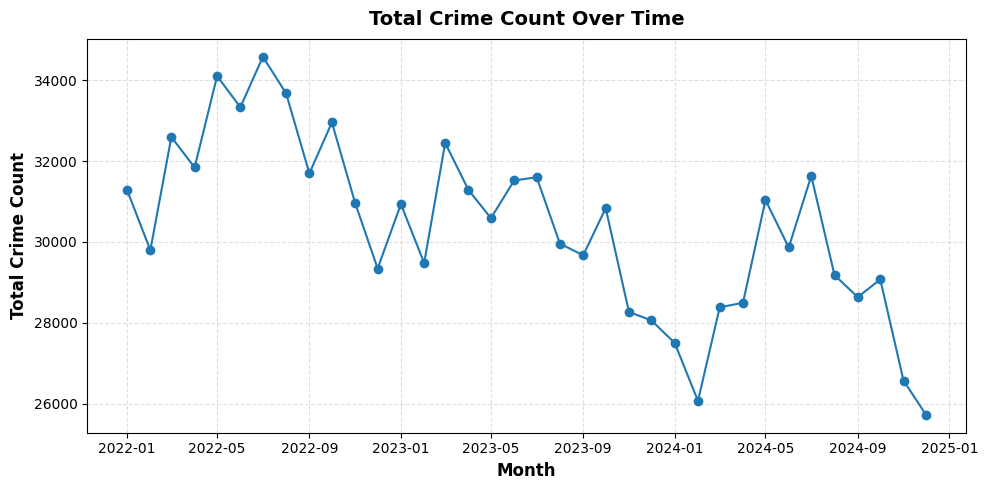

In [ ]:
# Visualizing Crime Trends Over Time

# Convert 'Month' to datetime (e.g., "Jan 2022")
df_street_Final['Month'] = pd.to_datetime(df_street_Final['Month'], format='%b %Y')

# Group by 'Month' and 'LSOA code and LSOA name', count the occurrences, and sort by 'Month'
Crime_Month_LSOA_Name = (df_street_Final.groupby(["Month", "LSOA code", "LSOA name"]).agg({'Crime ID': 'count'}).sort_values(by='Month').reset_index())
Crime_Month_LSOA_Name.rename(columns={'Crime ID': 'Crime Count'}, inplace=True)
Crime_Month_LSOA_Name['Year'] = Crime_Month_LSOA_Name['Month'].dt.year
Crime_Month_LSOA_Name['Month_Num'] = Crime_Month_LSOA_Name['Month'].dt.month
Crime_Month_LSOA_Name['Quarter'] = Crime_Month_LSOA_Name['Month'].dt.quarter

# Group by 'Month' and sum the 'Crime Count' for each month
monthly_crime_count = Crime_Month_LSOA_Name.groupby('Month')['Crime Count'].sum().reset_index()

# Create a time series plot
plt.figure(figsize=(10, 5))
plt.plot(monthly_crime_count['Month'], monthly_crime_count['Crime Count'], marker="o")
plt.title('Total Crime Count Over Time', fontsize=14, fontweight='bold', pad = 10)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Crime Count', fontsize=12, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


### **Heat Map of crime count distribution against LSOA cities and Month**

Creating a heatmap to visualize the distribution of crime counts across LSOA cities and months.

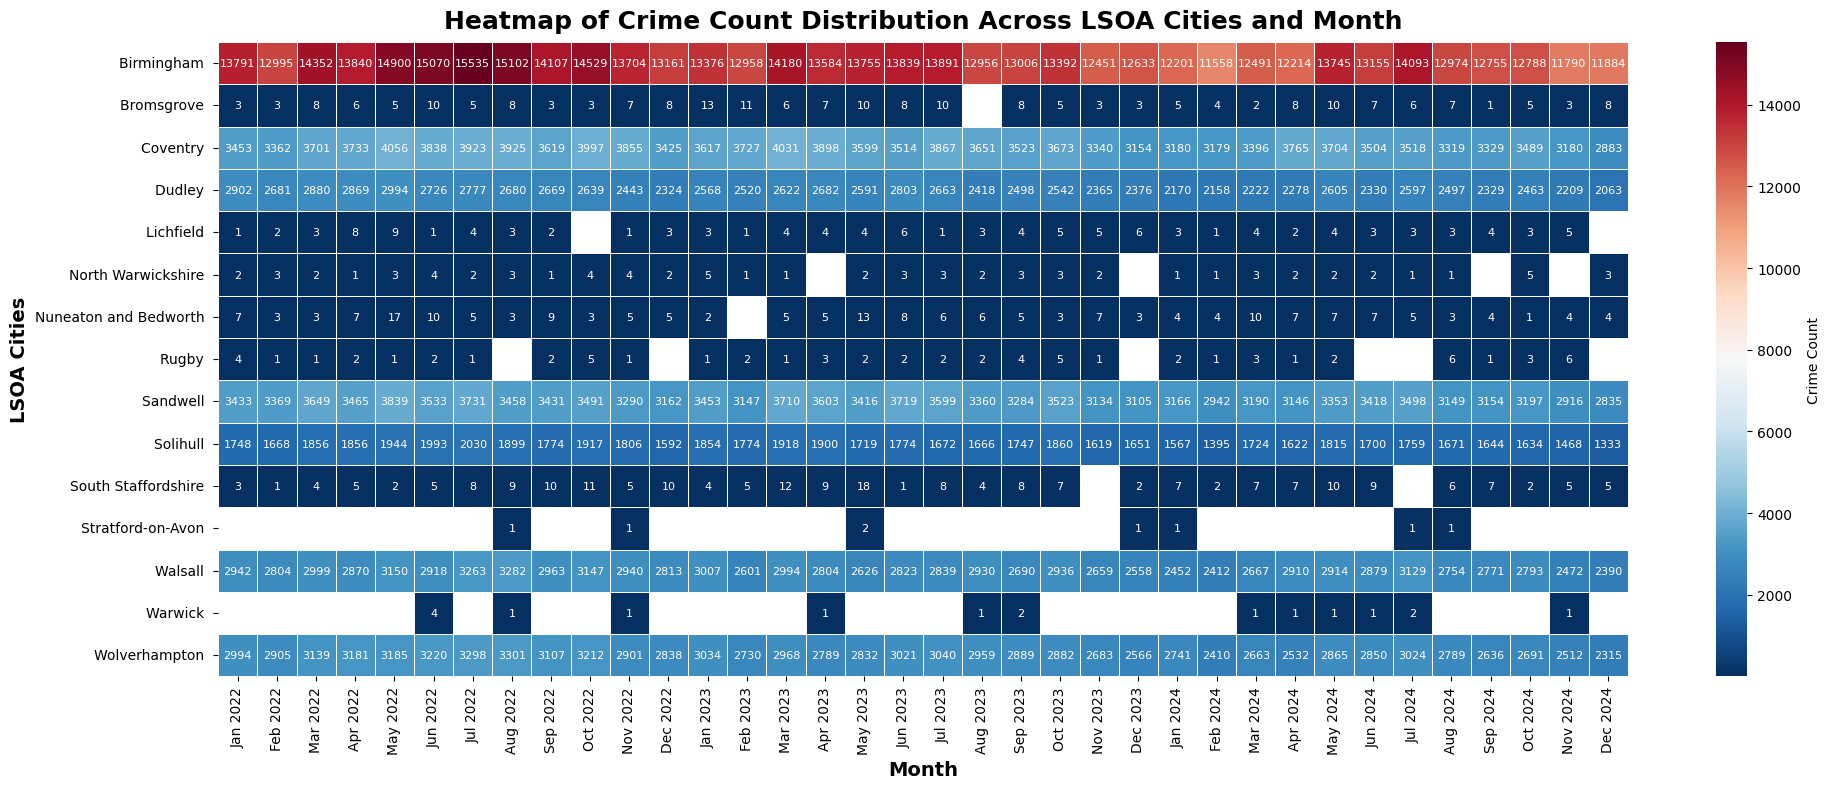

In [ ]:
# LSOA City level Heat Map
df_street_Final['LSOA City'] = df_street_Final['LSOA name'].str[:-4]
df_street_Final['Month'] = pd.to_datetime(df_street_Final['Month'], format='%b %Y')

# Group by 'Month' and 'LSOA City', count the occurrences, and sort by 'Month'
Crime_Month_LSOA_City = (
    df_street_Final.groupby(['Month', 'LSOA City']).size().reset_index(name='Crime Count').sort_values(by='Month')
)

# Format 'Month' and reset index
Crime_Month_LSOA_City['Month'] = Crime_Month_LSOA_City['Month'].dt.strftime('%b %Y')
Crime_Month_LSOA_City.reset_index(drop=True, inplace=True)

# Sample DataFrame (Ensure your dataframe is correctly loaded here)
Crime_Month_LSOA_City['Month'] = pd.to_datetime(Crime_Month_LSOA_City['Month'], format='%b %Y')
Crime_Month_LSOA_City = Crime_Month_LSOA_City.sort_values(by='Month')

# Pivot table to aggregate data by Month and LSOA code
pivot_data = Crime_Month_LSOA_City.pivot_table(index='LSOA City', columns='Month', values='Crime Count', aggfunc='mean')

# Format the 'Month' for better display (as "Jan 2022", "Feb 2022", etc.)
pivot_data.columns = pivot_data.columns.strftime('%b %Y')

# Set the figure size
plt.figure(figsize=(20, 8))

# Create a custom colormap (Spectral with enhanced brightness)
cmap = plt.cm.RdBu_r

# Apply normalization to spread out the data values more effectively
norm = mcolors.Normalize(vmin=pivot_data.min().min(), vmax=pivot_data.max().max())

# Heatmap with adjusted color scaling for brightness
sns.heatmap(pivot_data, annot=True, cmap=cmap, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Crime Count'}, annot_kws={'size': 8}, norm=norm)

# Add title and labels with improved font sizes and styling
plt.title("Heatmap of Crime Count Distribution Across LSOA Cities and Month", fontsize=18, fontweight='bold', color='black', pad=10)
plt.xlabel("Month", fontsize=14, fontweight='bold', color='black')
plt.ylabel("LSOA Cities", fontsize=14, fontweight='bold', color='black')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

### **Handling Outliers**

Detecting outliers in crime counts for each LSOA city using IQR-based method for lower and upper bounds.

In [ ]:
# Calculate IQR and outlier detection within each LSOA City (group-wise)
def detect_outliers(group):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = group['Crime Count'].quantile(0.25)
    Q3 = group['Crime Count'].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate Lower and Upper Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify Lower and Upper outliers
    lower_outliers = group[group['Crime Count'] < lower_bound]
    upper_outliers = group[group['Crime Count'] > upper_bound]

    # Add 'Outlier Type' column to each set of outliers
    lower_outliers['Outlier Type'] = 'Lower'
    upper_outliers['Outlier Type'] = 'Upper'

    # Combine the lower and upper outliers into one dataframe
    return pd.concat([lower_outliers, upper_outliers])

# Apply outlier detection by city (LSOA City)
outliers_by_city = Crime_Month_LSOA_City.groupby('LSOA City').apply(detect_outliers).reset_index(drop=True)

# Display the outliers along with the 'Outlier Type' column
print("Outliers detected within each city:\n", outliers_by_city[['Month', 'LSOA City', 'Crime Count', 'Outlier Type']])

Outliers detected within each city:
         Month               LSOA City  Crime Count Outlier Type
0  2022-04-01              Lichfield             8        Upper
1  2022-05-01              Lichfield             9        Upper
2  2023-01-01     North Warwickshire             5        Upper
3  2024-10-01     North Warwickshire             5        Upper
4  2022-05-01  Nuneaton and Bedworth            17        Upper
5  2023-05-01  Nuneaton and Bedworth            13        Upper
6  2024-12-01               Solihull          1333        Lower
7  2023-05-01    South Staffordshire            18        Upper
8  2023-05-01      Stratford-on-Avon             2        Upper
9  2022-06-01                Warwick             4        Upper
10 2023-09-01                Warwick             2        Upper
11 2024-07-01                Warwick             2        Upper


The detected outliers are minimal and have a negligible impact on the overall crime counts.

Given their limited effect on the data, we will proceed with considering this data in our analysis and modeling without making adjustments.

## 2. **Geospatial Analysis**  
   - Generated a **geographical visualization** to plot crime hotspots using LSOA-level data, offering insights into spatial crime patterns.  
   - Constructed a **heat map for top LSOA regions** with high crime rates to assist in targeted interventions and resource allocation.  

### **Heat Map for Top LSOA Names**

In [ ]:
df3 = df_street_Final.copy()
df3['Month'] = pd.to_datetime(df3['Month'], format='%b %Y')
df_month = df3.groupby(['Month']).size().reset_index(name='Crime Count')
df4 = df3.groupby(['Month', 'LSOA name']).size().reset_index(name='Crime Count')
df4 = df4.sort_values(by=['LSOA name', 'Month'], ascending=[True, True])
df4 = df4.reset_index(drop=True)
df4

,Month,LSOA name,Crime Count
0,2022-01-01,Birmingham 001A,5
1,2022-02-01,Birmingham 001A,5
2,2022-03-01,Birmingham 001A,5
3,2022-04-01,Birmingham 001A,2
4,2022-05-01,Birmingham 001A,11
...,...,...,...
62074,2024-08-01,Wolverhampton 035J,12
62075,2024-09-01,Wolverhampton 035J,4
62076,2024-10-01,Wolverhampton 035J,7
62077,2024-11-01,Wolverhampton 035J,6


In [ ]:
df4_lsoaname = df4.groupby('LSOA name')[['Crime Count']].sum().reset_index()
df4_lsoaname = df4_lsoaname.sort_values('Crime Count', ascending = False)

top20 = df4_lsoaname.head(20)
top10 = df4_lsoaname.head(10)
top5 = df4_lsoaname.head(5)

df4_top20 = df4[df4["LSOA name"].isin(top20["LSOA name"])].copy()
df4_top10 = df4[df4["LSOA name"].isin(top10["LSOA name"])].copy()
df4_top5 = df4[df4["LSOA name"].isin(top5["LSOA name"])].copy()

top10

,LSOA name,Crime Count
659,Birmingham 138A,16870
642,Birmingham 135C,7816
1610,Walsall 030A,6916
255,Birmingham 050F,5969
254,Birmingham 050E,5821
851,Coventry 031C,5485
1760,Wolverhampton 020F,4609
1373,Solihull 009A,4192
636,Birmingham 134B,3865
1024,Dudley 022A,3820


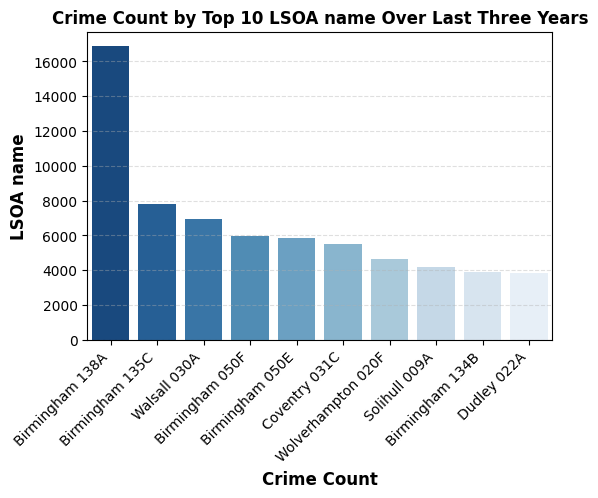

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=top10, x="LSOA name", y="Crime Count", hue="LSOA name", palette="Blues_r", legend=False)

plt.ylabel('LSOA name', fontsize=12, fontweight='bold')
plt.xlabel('Crime Count', fontsize=12, fontweight='bold')
plt.title('Crime Count by Top 10 LSOA name Over Last Three Years', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right')

plt.savefig('Crime Count by Top 10 LSOA name Over Last Three Years 1.png', dpi=600, bbox_inches="tight")
plt.show()

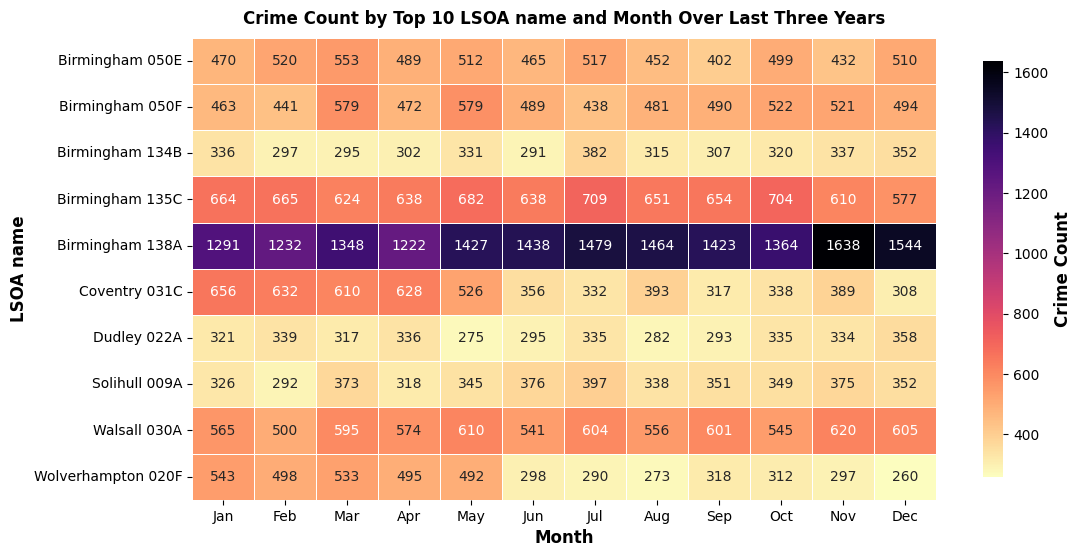

In [ ]:
# Data processing: Extract “Year” and “Month” into separate columns
df_heat = df4_top10.copy()
df_heat["Year"] = df_heat["Month"].dt.year
df_heat["Month"] = df_heat["Month"].dt.strftime("%b")  # Convert “Month” to format like “Jan”, “Feb”, etc.

# Create Pivot Table: LSOA name vs. Month, filled with Crime Count
heatmap_data = df_heat.pivot_table(index="LSOA name", columns="Month", values="Crime Count", aggfunc="sum")

# Set the correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data = heatmap_data[month_order]  # Sort by month

plt.figure(figsize=(12, 6))
ax = sns.heatmap(heatmap_data, cmap="magma_r", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Crime Count',  'shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Crime Count', fontsize=12, fontweight='bold')

plt.title("Crime Count by Top 10 LSOA name and Month Over Last Three Years", fontsize=12, fontweight='bold',pad= 10)
plt.xlabel("Month", fontweight='bold', fontsize=12)
plt.ylabel("LSOA name", fontweight='bold', fontsize=12)

plt.savefig('Crime Count by Top 10 LSOA name and Month Over Last Three Years.png', dpi=600, bbox_inches="tight")
plt.show()

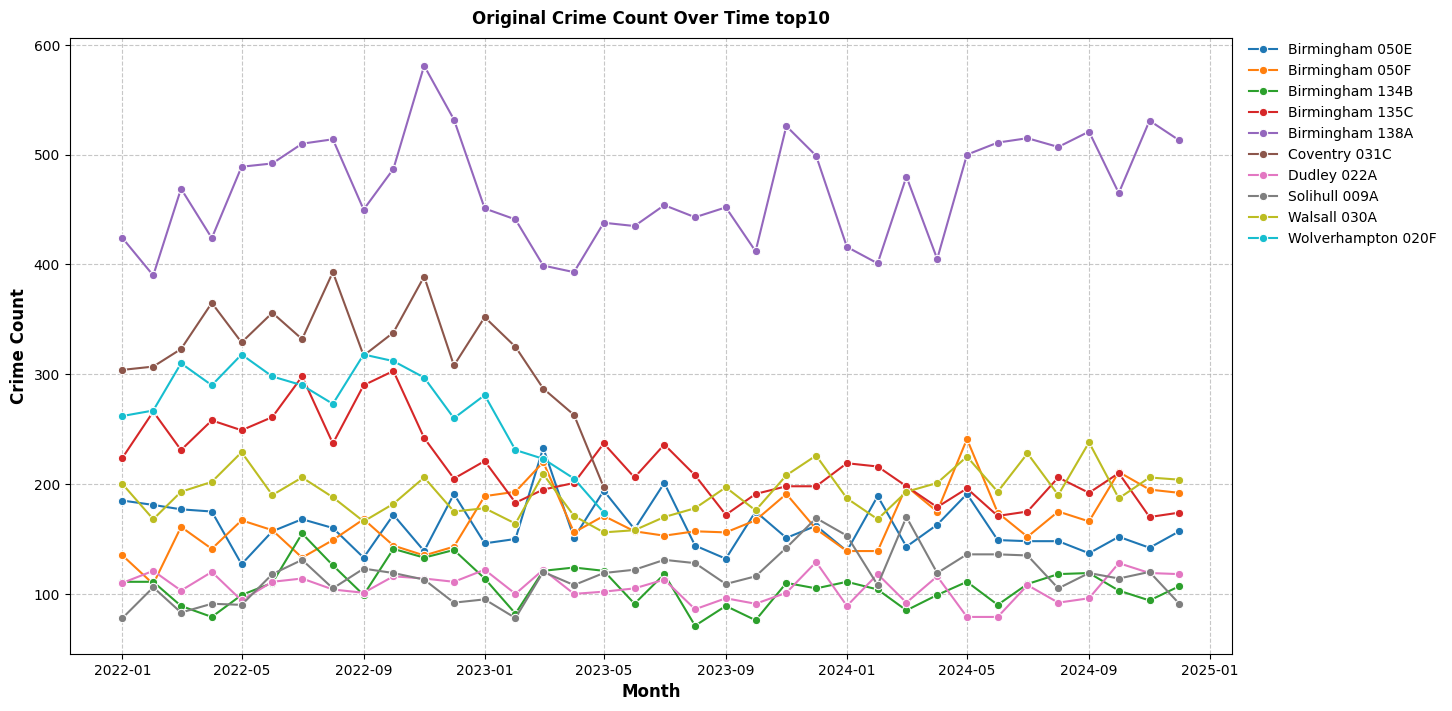

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df4_top10, x='Month', y='Crime Count', hue='LSOA name', marker='o')

plt.title('Original Crime Count Over Time top10', fontsize=12, fontweight='bold',pad= 10)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Crime Count', fontsize=12, fontweight='bold')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01,1), loc=2, borderaxespad=0.0, frameon=False)
#plt.savefig('Original Crime Count Over Time top10.png', dpi=600, bbox_inches="tight")

plt.show()

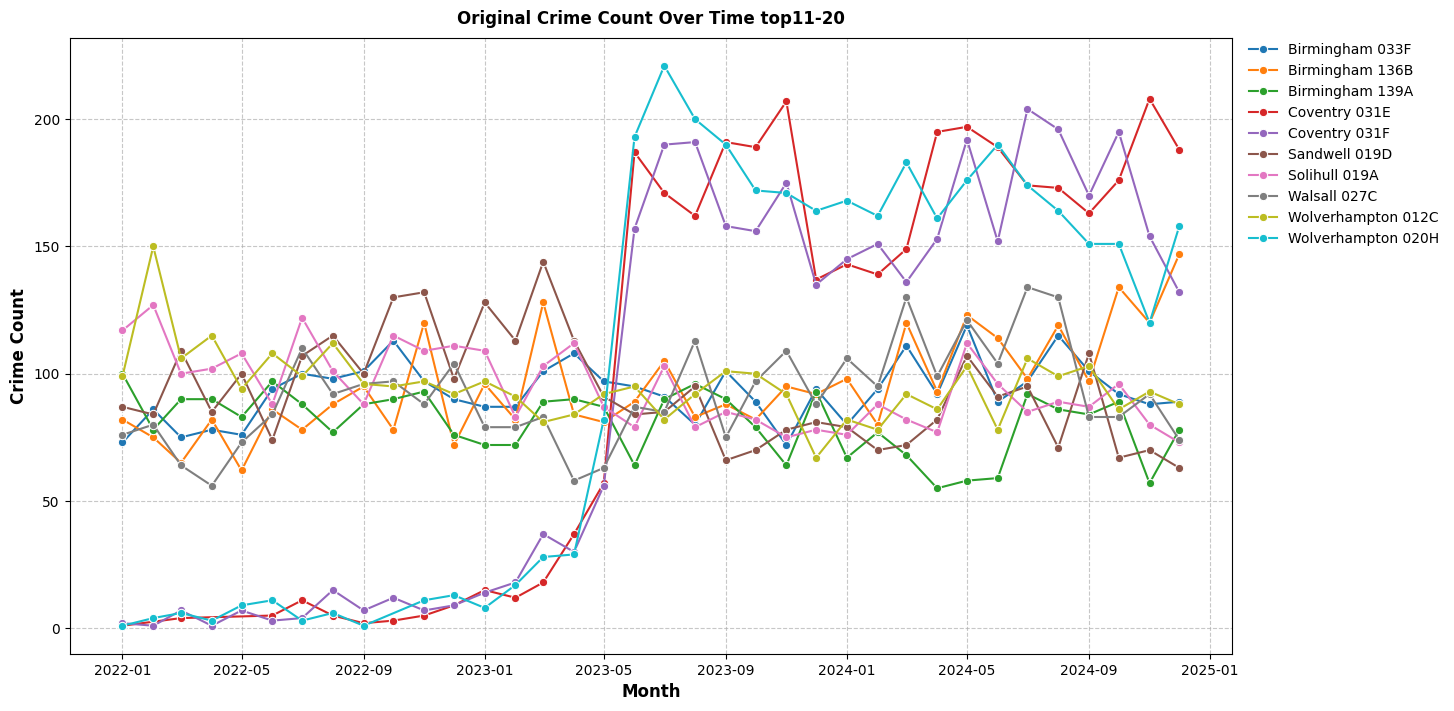

In [ ]:
df4_top11_20 = df4[df4["LSOA name"].isin(set(top20["LSOA name"]) - set(top10["LSOA name"]))].copy()

plt.figure(figsize=(15, 8))
sns.lineplot(data=df4_top11_20, x='Month', y='Crime Count', hue='LSOA name', marker='o')

plt.title('Original Crime Count Over Time top11-20', fontsize=12, fontweight='bold',pad= 10)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Crime Count', fontsize=12, fontweight='bold')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01,1), loc=2, borderaxespad=0.0, frameon=False)
plt.show()

In [ ]:
df4_lsoaname_labeled = df4_lsoaname.copy()

def classify_crime_count(count):
    if count >= 4000:
        return "Very High Crime Area (≥5000)"
    elif 3000 <= count < 5000:
        return "High Crime Area (3000 - 4999)"
    elif 1000 <= count < 3000:
        return "Moderate Crime Area (1000 - 2999)"
    elif 500 <= count < 1000:
        return "Low Crime Area (500 - 999)"
    else:
        return "Very Low Crime Area (<500)"

df4_lsoaname_labeled["Crime Count Label"] = df4_lsoaname_labeled["Crime Count"].apply(classify_crime_count)

df4_lsoaname_classify = df4_lsoaname_labeled.groupby('Crime Count Label').agg(number_of_LSOA_name=('LSOA name', 'count'),
                                                                              total_crime_count=('Crime Count', 'sum')
                                                                             ).reset_index().rename(columns={"number_of_LSOA_name": "Number of LSOA name",
                                                                                                             "total_crime_count": "Total Crime Count"})
df4_lsoaname_classify['Crime Count ratio'] = (df4_lsoaname_classify["Number of LSOA name"] / df4_lsoaname_classify["Number of LSOA name"].sum() * 100).round(2).astype(float).astype(str) + "%"
df4_lsoaname_classify['Number of LSOA name ratio'] = (df4_lsoaname_classify["Total Crime Count"] / df4_lsoaname_classify["Total Crime Count"].sum() * 100).round(2).astype(float).astype(str) + "%"
df4_lsoaname_classify['Average count for each LSOA name'] = (df4_lsoaname_classify["Total Crime Count"] / df4_lsoaname_classify["Number of LSOA name"]).round(0).astype(int)

df4_lsoaname_classify

,Crime Count Label,Number of LSOA name,Total Crime Count,Crime Count ratio,Number of LSOA name ratio,Average count for each LSOA name
0,High Crime Area (3000 - 4999),11,38327,0.6%,3.51%,3484
1,Low Crime Area (500 - 999),605,419769,33.1%,38.41%,694
2,Moderate Crime Area (1000 - 2999),189,273087,10.34%,24.99%,1445
3,Very High Crime Area (≥5000),8,57678,0.44%,5.28%,7210
4,Very Low Crime Area (<500),1015,304141,55.53%,27.83%,300


In [ ]:
df4_2022 = df4[df4["Month"] <= "2022-12-01"].copy()

df4_2022_lsoaname = df4_2022.groupby('LSOA name')[['Crime Count']].sum().reset_index()
df4_2022_lsoaname = df4_2022_lsoaname.sort_values('Crime Count', ascending = False)
top10_2022 = df4_2022_lsoaname.head(10).reset_index(drop=True)

df4_2022_top10 = df4_2022[df4_2022["LSOA name"].isin(top10_2022["LSOA name"])].copy()
top10_2022

,LSOA name,Crime Count
0,Birmingham 138A,5762
1,Coventry 031C,4061
2,Wolverhampton 020F,3495
3,Birmingham 135C,3064
4,Walsall 030A,2305
5,Birmingham 050E,1965
6,Birmingham 050F,1743
7,Birmingham 134B,1393
8,Dudley 022A,1319
9,Solihull 019A,1288


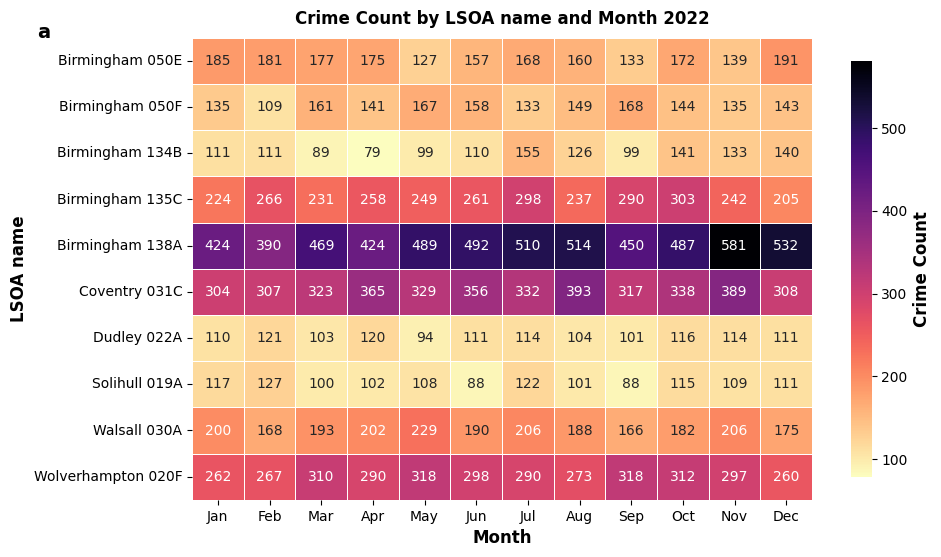

In [ ]:
# Data processing: Extract “Year” and “Month” into separate columns
df_heat = df4_2022_top10.copy()
df_heat["Year"] = df_heat["Month"].dt.year
df_heat["Month"] = df_heat["Month"].dt.strftime("%b")  # Convert “Month” to format like “Jan”, “Feb”, etc.

# Create Pivot Table: LSOA name vs. Month, filled with Crime Count
heatmap_data = df_heat.pivot_table(index="LSOA name", columns="Month", values="Crime Count", aggfunc="sum")

# Set the correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data = heatmap_data[month_order]  # Sort by month

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, cmap="magma_r", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Crime Count','shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Crime Count', fontsize=12, fontweight='bold')

plt.title("Crime Count by LSOA name and Month 2022", fontsize=12, fontweight='bold',pad= 10)
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("LSOA name", fontsize=12, fontweight='bold')
plt.text(-0.25, 1, 'a', fontsize=14, fontweight='bold', transform=plt.gca().transAxes)

#plt.savefig('Crime Count by LSOA name and Month 2022.png', dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
df4_2023 = df4[(df4["Month"] >= "2023-01-01") & (df4["Month"] <= "2023-12-01")].copy()

df4_2023_lsoaname = df4_2023.groupby('LSOA name')[['Crime Count']].sum().reset_index()
df4_2023_lsoaname = df4_2023_lsoaname.sort_values('Crime Count', ascending = False)
top10_2023 = df4_2023_lsoaname.head(10).reset_index(drop=True)

df4_2023_top10 = df4_2023[df4_2023["LSOA name"].isin(top10_2023["LSOA name"])].copy()
top10_2023

,LSOA name,Crime Count
0,Birmingham 138A,5343
1,Birmingham 135C,2446
2,Walsall 030A,2191
3,Birmingham 050F,2069
4,Birmingham 050E,1998
5,Wolverhampton 020H,1475
6,Solihull 009A,1437
7,Coventry 031C,1424
8,Coventry 031E,1383
9,Coventry 031F,1317


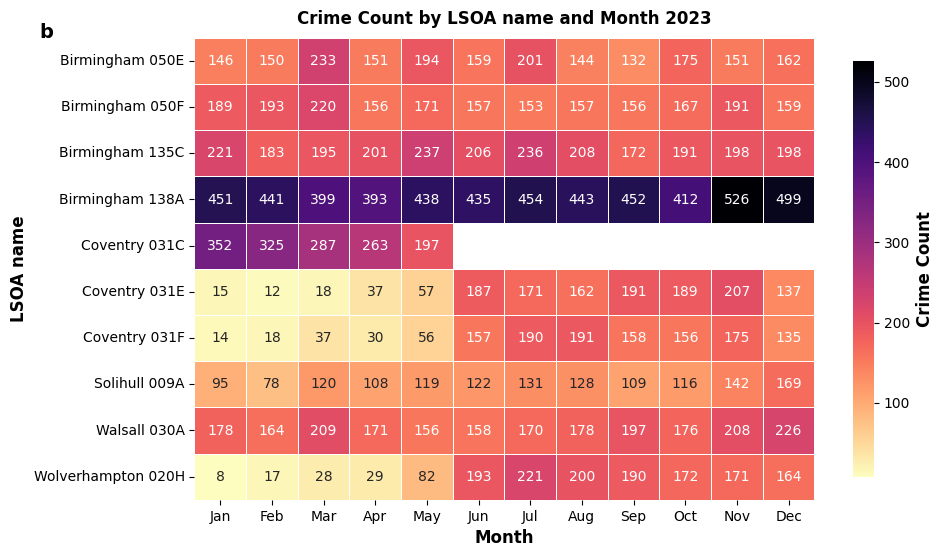

In [ ]:
# Data processing: Extract “Year” and “Month” into separate columns
df_heat = df4_2023_top10.copy()
df_heat["Year"] = df_heat["Month"].dt.year
df_heat["Month"] = df_heat["Month"].dt.strftime("%b")  # Convert “Month” to format like “Jan”, “Feb”, etc.

# Create Pivot Table: LSOA name vs. Month, filled with Crime Count
heatmap_data = df_heat.pivot_table(index="LSOA name", columns="Month", values="Crime Count", aggfunc="sum")

# Set the correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data = heatmap_data[month_order]  # Sort by month

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, cmap="magma_r", annot=True, fmt=".0f", linewidths=0.5,cbar_kws={'label': 'Crime Count', 'shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Crime Count', fontsize=12, fontweight='bold') # Include numeric annotations

plt.title("Crime Count by LSOA name and Month 2023", fontsize=12, fontweight='bold',pad= 10)
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("LSOA name", fontsize=12, fontweight='bold')
plt.text(-0.25, 1, 'b', fontsize=14, fontweight='bold', transform=plt.gca().transAxes)

#plt.savefig('Crime Count by LSOA name and Month 2023.png', dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
df4_2024 = df4[df4["Month"] >= "2024-01-01"].copy()

df4_2024_lsoaname = df4_2024.groupby('LSOA name')[['Crime Count']].sum().reset_index()
df4_2024_lsoaname = df4_2024_lsoaname.sort_values('Crime Count', ascending = False)
top10_2024 = df4_2024_lsoaname.head(10).reset_index(drop=True)

df4_2024_top10 = df4_2024[df4_2024["LSOA name"].isin(top10_2024["LSOA name"])].copy()
top10_2024

,LSOA name,Crime Count
0,Birmingham 138A,5765
1,Walsall 030A,2420
2,Birmingham 135C,2306
3,Birmingham 050F,2157
4,Coventry 031E,2094
5,Coventry 031F,1980
6,Wolverhampton 020H,1958
7,Birmingham 050E,1858
8,Solihull 009A,1506
9,Birmingham 136B,1343


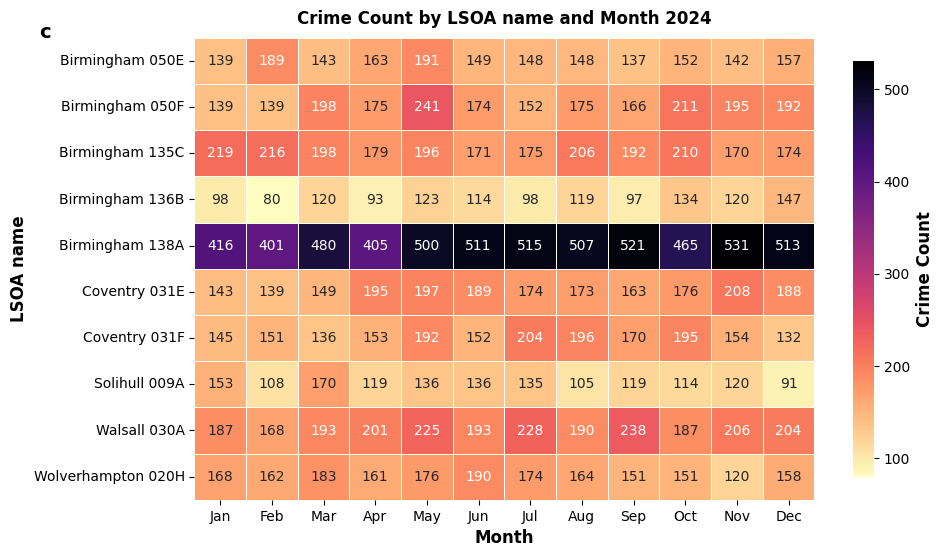

In [ ]:
# Data processing: Extract “Year” and “Month” into separate columns
df_heat = df4_2024_top10.copy()
df_heat["Year"] = df_heat["Month"].dt.year
df_heat["Month"] = df_heat["Month"].dt.strftime("%b")  # Convert “Month” to format like “Jan”, “Feb”, etc.

# Create Pivot Table: LSOA name vs. Month, filled with Crime Count
heatmap_data = df_heat.pivot_table(index="LSOA name", columns="Month", values="Crime Count", aggfunc="sum")

# Set the correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data = heatmap_data[month_order]  # Sort by month

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, cmap="magma_r", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Crime Count', 'shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Crime Count', fontsize=12, fontweight='bold')

plt.title("Crime Count by LSOA name and Month 2024", fontsize=12, fontweight='bold',pad= 10)
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("LSOA name", fontsize=12, fontweight='bold')
plt.text(-0.25, 1, 'c', fontsize=14, fontweight='bold', transform=plt.gca().transAxes)

#plt.savefig('Crime Count by LSOA name and Month 2024.png', dpi=600, bbox_inches="tight")
plt.show()

### **Geographical Visualization**

Converting the data to a GeoDataFrame and visualizing crime distribution on a geographical map.


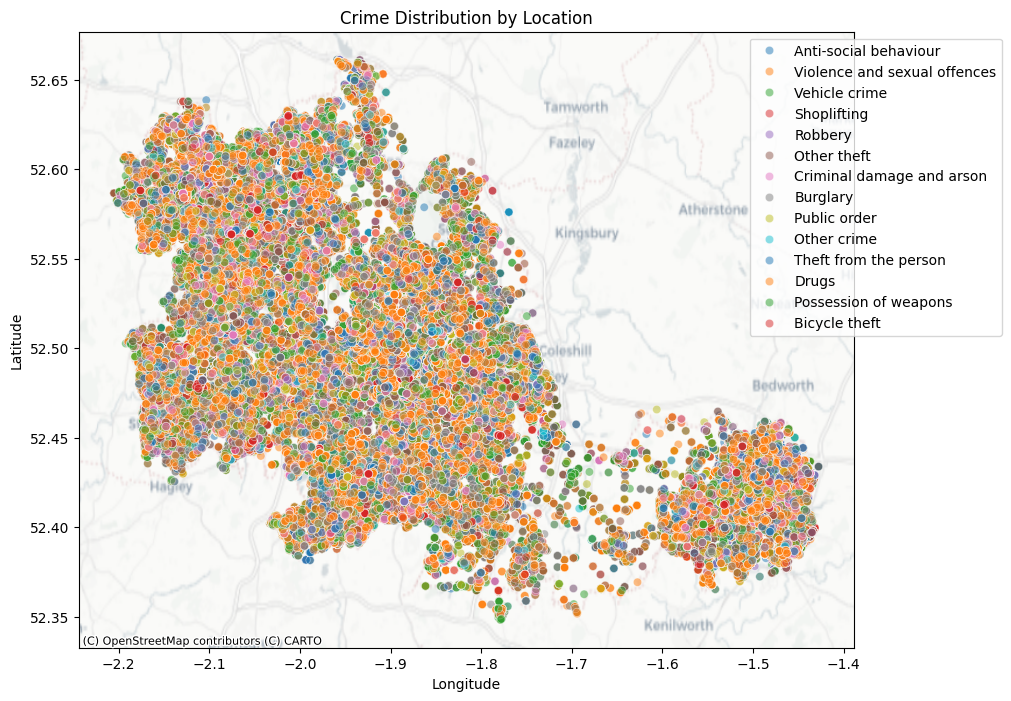

In [ ]:
# Create a GeoDataFrame from your data (ensure the columns are in the correct projection for geographic data)
gdf = gpd.GeoDataFrame(df_street_Final, geometry=gpd.points_from_xy(df_street_Final.Longitude, df_street_Final.Latitude))

# Set the CRS to WGS84 (EPSG:4326), as the data uses lat/lon
gdf.set_crs("EPSG:4326", allow_override=True, inplace=True)

# Plot the scatterplot with the background map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the background map using contextily
# gdf.plot(ax=ax, alpha=0.3, color='lightgrey', edgecolor='k')  # Optional: Add a background color for context

# Plot the data points with different colors for each 'Crime type'
sns.scatterplot(x='Longitude', y='Latitude', hue='Crime type', data=df_street_Final, palette='tab10', alpha=0.5, ax=ax)

# Add basemap using contextily
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)

# Customize the plot
plt.title('Crime Distribution by Location')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# **Data Modelling and Visualizing Insights**

In this project, we aimed to address two key research questions:

1. **Crime Hotspot Identification:** Which LSOA (Lower Layer Super Output Areas) in the UK have historically exhibited high crime rates, and how do spatial and temporal patterns influence crime concentration over time?

2. **Predicting Future Crime Hotspots:** How accurately can time-series models and predictive techniques forecast future crime hotspots based on historical crime data?

To solve this problem, we leveraged several models designed to capture both the temporal and spatial dimensions of crime data:

## **Prophet Model**

We used Prophet for time-series forecasting, ideal for capturing seasonal patterns and trends in crime data. It provides forecasts that allow us to predict future crime trends over different time periods.

### **Data Preparation & Feature Engineering**

In [ ]:
# Perform Grouping by Month and LSOA code
df_street_Final['Month'] = pd.to_datetime(df_street_Final['Month'])
Pro_crime_count = df_street_Final.groupby(["Month", "LSOA code"]).size().reset_index(name='Crime Count')
Pro_crime_count = Pro_crime_count.sort_values(by=['LSOA code', 'Month'])
Pro_crime_count.reset_index(drop=True, inplace=True)

Pro_crime_count

,Month,LSOA code,Crime Count
0,2022-01-01,E01008881,23
1,2022-02-01,E01008881,20
2,2022-03-01,E01008881,32
3,2022-04-01,E01008881,20
4,2022-05-01,E01008881,58
...,...,...,...
61936,2024-08-01,E01034955,16
61937,2024-09-01,E01034955,14
61938,2024-10-01,E01034955,21
61939,2024-11-01,E01034955,12


### **Model Training and Evaluation**

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp51z2ci4z/en39zyb6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp51z2ci4z/xec_sv9n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=44045', 'data', 'file=/tmp/tmp51z2ci4z/en39zyb6.json', 'init=/tmp/tmp51z2ci4z/xec_sv9n.json', 'output', 'file=/tmp/tmp51z2ci4z/prophet_modelwel6ysdr/prophet_model-20250328000636.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
00:06:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:06:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonali

Hotspot for month:  2025-01-01 00:00:00
     LSOA code  Predicted Crime
7    E01008884               54
12   E01008887               48
32   E01008881               34
34   E01008889               33
37   E01008890               32
43   E01008886               30
70   E01008888               20
75   E01008885               18
82   E01008883               16
114  E01008882                7


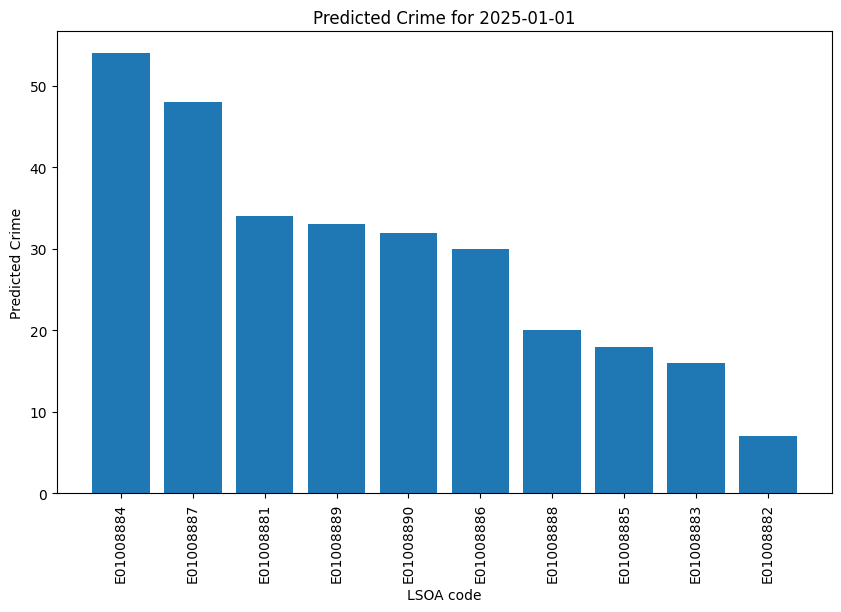

Hotspot for month:  2025-02-01 00:00:00
     LSOA code  Predicted Crime
0    E01008887               70
24   E01008886               38
31   E01008884               34
55   E01008889               26
57   E01008890               26
61   E01008881               24
71   E01008883               19
94   E01008888               13
98   E01008885               11
119  E01008882                2


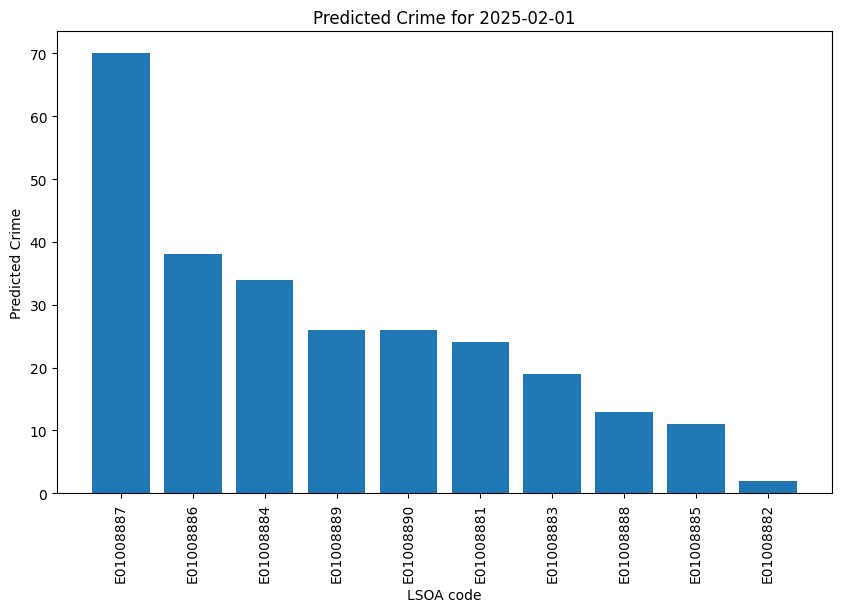

Hotspot for month:  2025-03-01 00:00:00
     LSOA code  Predicted Crime
6    E01008887               57
27   E01008884               36
29   E01008881               35
38   E01008886               31
45   E01008889               29
66   E01008890               22
80   E01008883               17
96   E01008888               12
99   E01008882               11
102  E01008885               10


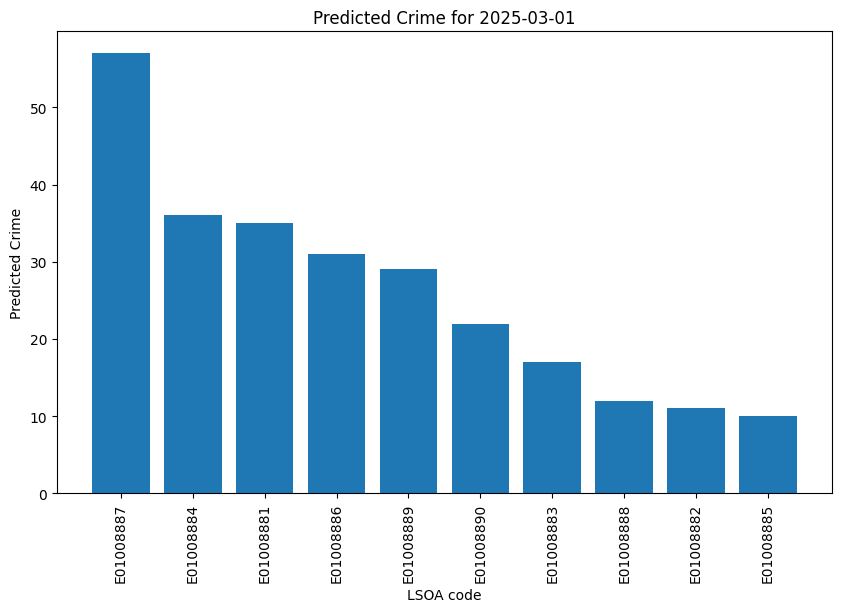

Hotspot for month:  2025-04-01 00:00:00
     LSOA code  Predicted Crime
5    E01008887               58
35   E01008881               32
39   E01008886               31
49   E01008884               28
53   E01008889               27
78   E01008890               18
87   E01008883               14
93   E01008888               13
108  E01008885                9
115  E01008882                7


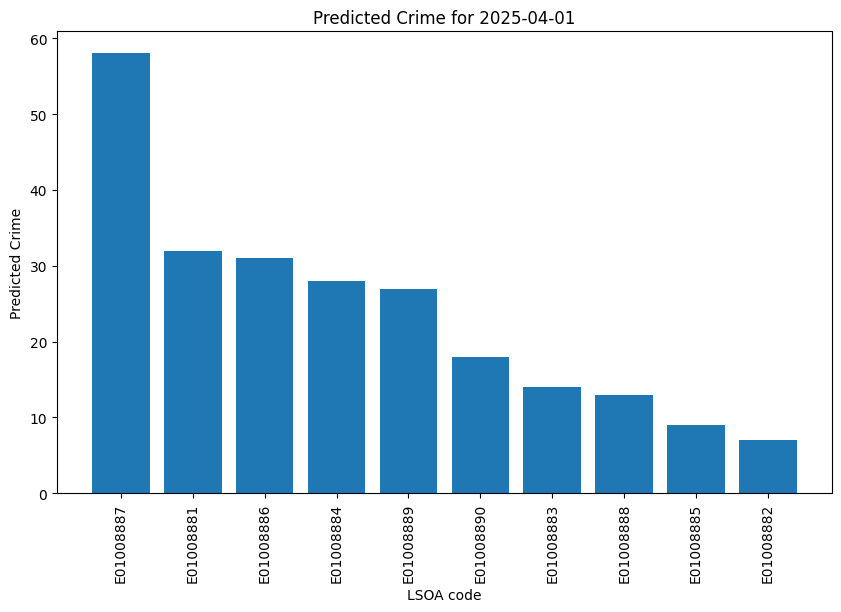

Hotspot for month:  2025-05-01 00:00:00
     LSOA code  Predicted Crime
8    E01008881               53
11   E01008887               49
15   E01008886               42
22   E01008884               38
47   E01008889               28
58   E01008883               25
60   E01008890               24
91   E01008885               13
107  E01008888               10
111  E01008882                8


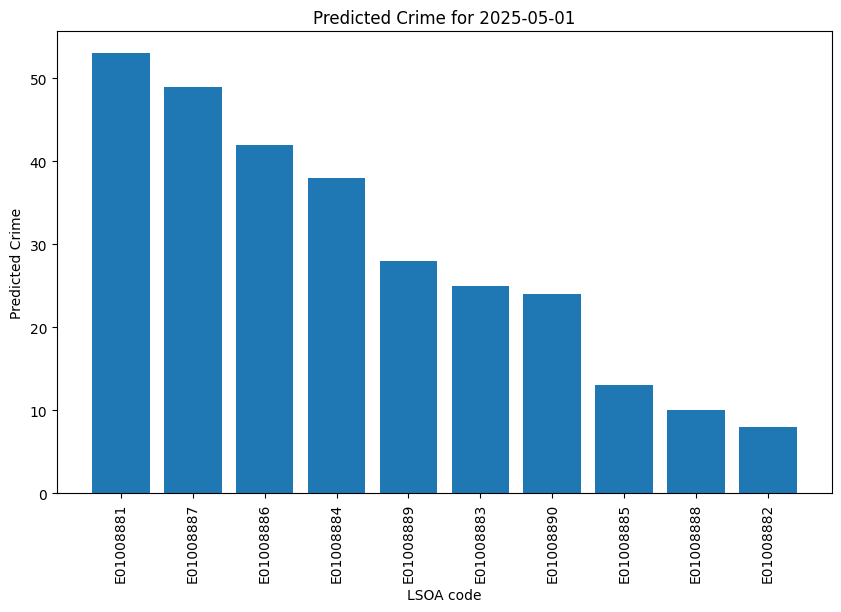

Hotspot for month:  2025-06-01 00:00:00
     LSOA code  Predicted Crime
9    E01008887               51
18   E01008886               39
26   E01008884               37
28   E01008881               36
54   E01008889               27
68   E01008890               21
83   E01008883               16
104  E01008888               10
112  E01008885                8
117  E01008882                7


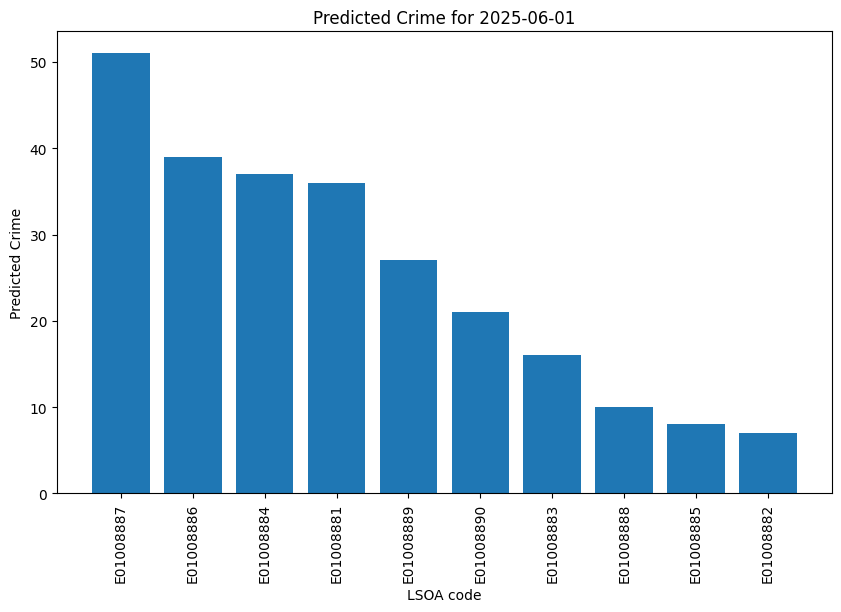

In [ ]:
hotspot_predictions = {}
for lsoa in Pro_crime_count['LSOA code'].unique()[:10]:
  try:
      lsoa_df = Pro_crime_count[Pro_crime_count['LSOA code'] == lsoa]
      lsoa_df = lsoa_df.reset_index(drop=True)
      lsoa_df = lsoa_df[['Month', 'Crime Count']].rename(columns={"Month": "ds", "Crime Count": "y"})
      lsoa_df['ds'] = pd.to_datetime(lsoa_df['ds'])
      model = Prophet()
      model.fit(lsoa_df)
      # Future prediction (next 6 months)
      last_date = lsoa_df['ds'].max()
      future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')
      future_dates = pd.DataFrame({'ds': future_dates})
      forecast = model.predict(future_dates)
      # Store future values
      hotspot_predictions[lsoa] = forecast[['ds', 'yhat']]
  except Exception as error:
      print(f"Failed for LSOA Code: {lsoa}")
future_crimes = []
# Aggregate predictions for each LSOA
for lsoa, pred in hotspot_predictions.items():
    for i, row in pred.iterrows():
        future_crimes.append((lsoa, row['ds'], int(row['yhat'])))
hotspot_df = pd.DataFrame(future_crimes, columns=['LSOA code', 'ds', 'Predicted Crime'])
hotspot_df = hotspot_df.sort_values(by=['Predicted Crime'], ascending=False)
hotspot_df.reset_index(drop=True, inplace=True)
for date in ["2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01", "2025-05-01", "2025-06-01"]:
    print("Hotspot for month: ", pd.to_datetime(date))
    print(hotspot_df[hotspot_df["ds"] == pd.to_datetime(date)][["LSOA code", "Predicted Crime"]])
    plt.figure(figsize=(10, 6))
    plt.bar(hotspot_df[hotspot_df["ds"] == pd.to_datetime(date)]["LSOA code"], hotspot_df[hotspot_df["ds"] == pd.to_datetime(date)]["Predicted Crime"])
    plt.xlabel("LSOA code")
    plt.ylabel("Predicted Crime")
    plt.xticks(rotation=90)
    plt.title("Predicted Crime for " + date)
    plt.show()

## **Multi-Layer Perceptron Model**

MLP is a neural network model that helps capture complex, non-linear relationships between crime counts and various features like time and location improving prediction accuracy.

### **Data Preparation and Feature Engineering**

In [ ]:
MLP_df_M=df4.copy()
MLP_df_M = MLP_df_M.sort_values(by=['LSOA name', 'Month'], ascending=[True, True])
MLP_df_M

,Month,LSOA name,Crime Count
0,2022-01-01,Birmingham 001A,5
1,2022-02-01,Birmingham 001A,5
2,2022-03-01,Birmingham 001A,5
3,2022-04-01,Birmingham 001A,2
4,2022-05-01,Birmingham 001A,11
...,...,...,...
62074,2024-08-01,Wolverhampton 035J,12
62075,2024-09-01,Wolverhampton 035J,4
62076,2024-10-01,Wolverhampton 035J,7
62077,2024-11-01,Wolverhampton 035J,6


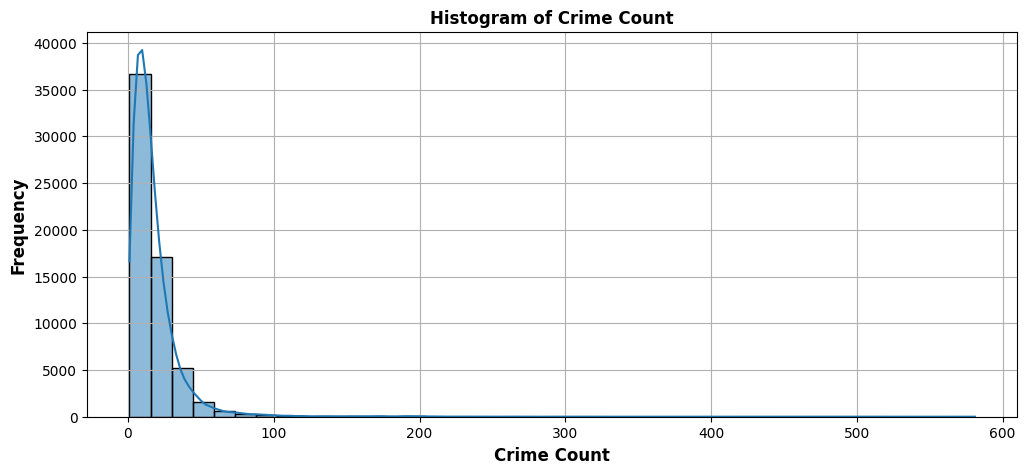

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(MLP_df_M['Crime Count'], bins=40, kde=True)
plt.xlabel('Crime Count',  fontsize=12, fontweight='bold')
plt.ylabel('Frequency',  fontsize=12, fontweight='bold')
plt.title('Histogram of Crime Count',  fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()

In [ ]:
# Extract time-based features
MLP_df_M["Year"] = MLP_df_M["Month"].dt.year
MLP_df_M["Year_Diff"] = MLP_df_M["Year"] - MLP_df_M["Year"].min()
MLP_df_M["Month_Num"] = MLP_df_M["Month"].dt.month  # 1-12 月份
MLP_df_M["Month_Sin"] = np.sin(2 * np.pi * MLP_df_M["Month_Num"] / 12)  # 周期特征
MLP_df_M["Month_Cos"] = np.cos(2 * np.pi * MLP_df_M["Month_Num"] / 12)

# Encode location feature (LSOA name) using frequency encoding
lsoa_freq = MLP_df_M["LSOA name"].value_counts() / len(MLP_df_M)
MLP_df_M["LSOA Freq"] = MLP_df_M["LSOA name"].map(lsoa_freq)

# Generate Lag Features and Rolling Averages to capture short-term and long-term trends
MLP_df_M["Crime Count Lag 1"] = MLP_df_M.groupby("LSOA name")["Crime Count"].shift(1)
MLP_df_M["Crime Count Lag 3"] = MLP_df_M.groupby("LSOA name")["Crime Count"].shift(3)
MLP_df_M["Crime Count Rolling Mean 3"] = MLP_df_M.groupby("LSOA name")["Crime Count"].rolling(3).mean().reset_index(0, drop=True)
MLP_df_M["Crime Count Rolling Mean 6"] = MLP_df_M.groupby("LSOA name")["Crime Count"].rolling(6).mean().reset_index(0, drop=True)

# Filling NaN values resulting from lag feature calculations with 0 to avoid losing data
MLP_df_M = MLP_df_M.fillna(0)

# Normalize “Crime Count” using RobustScaler, suitable for skewed distributions and insensitive to outliers
scaler = RobustScaler()
MLP_df_M["Crime Count Scaled"] = scaler.fit_transform(MLP_df_M[["Crime Count"]])

MLP_df_M

,Month,LSOA name,Crime Count,Year,Year_Diff,Month_Num,Month_Sin,Month_Cos,LSOA Freq,Crime Count Lag 1,Crime Count Lag 3,Crime Count Rolling Mean 3,Crime Count Rolling Mean 6,Crime Count Scaled
0,2022-01-01,Birmingham 001A,5,2022,0,1,5.000000e-01,8.660254e-01,0.00058,0.0,0.0,0.000000,0.000000,-0.571429
1,2022-02-01,Birmingham 001A,5,2022,0,2,8.660254e-01,5.000000e-01,0.00058,5.0,0.0,0.000000,0.000000,-0.571429
2,2022-03-01,Birmingham 001A,5,2022,0,3,1.000000e+00,6.123234e-17,0.00058,5.0,0.0,5.000000,0.000000,-0.571429
3,2022-04-01,Birmingham 001A,2,2022,0,4,8.660254e-01,-5.000000e-01,0.00058,5.0,5.0,4.000000,0.000000,-0.785714
4,2022-05-01,Birmingham 001A,11,2022,0,5,5.000000e-01,-8.660254e-01,0.00058,2.0,5.0,6.000000,0.000000,-0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62074,2024-08-01,Wolverhampton 035J,12,2024,2,8,-8.660254e-01,-5.000000e-01,0.00037,13.0,12.0,10.000000,10.500000,-0.071429
62075,2024-09-01,Wolverhampton 035J,4,2024,2,9,-1.000000e+00,-1.836970e-16,0.00037,12.0,5.0,9.666667,9.333333,-0.642857
62076,2024-10-01,Wolverhampton 035J,7,2024,2,10,-8.660254e-01,5.000000e-01,0.00037,4.0,13.0,7.666667,8.833333,-0.428571
62077,2024-11-01,Wolverhampton 035J,6,2024,2,11,-5.000000e-01,8.660254e-01,0.00037,7.0,12.0,5.666667,7.833333,-0.500000


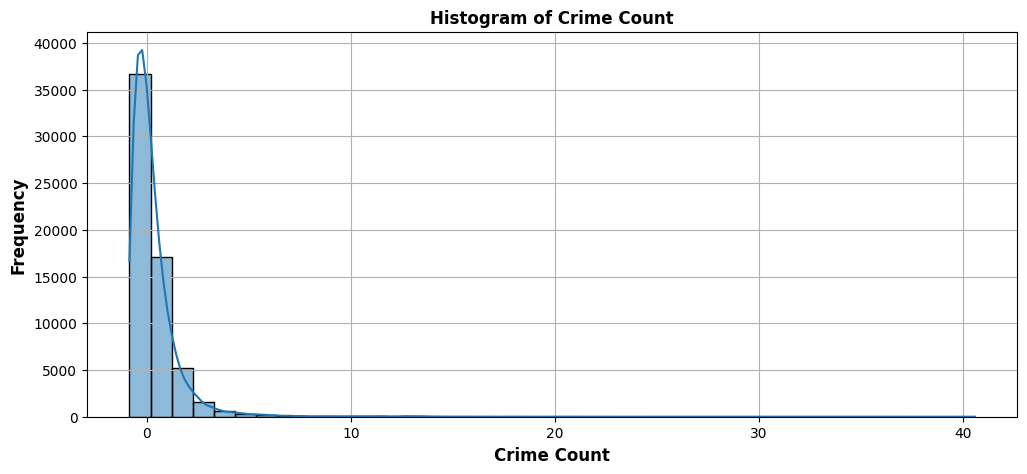

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(MLP_df_M['Crime Count Scaled'], bins=40, kde=True)
plt.xlabel('Crime Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Histogram of Crime Count', fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()

In [ ]:
np.random.seed(42)

# train/test split (2022.1-2024.1 for training, 2024.2-2024.12 for testing)
MLP_df_train = MLP_df_M[MLP_df_M["Month"] <= "2024-01-01"].copy()
MLP_df_validation = MLP_df_M[MLP_df_M["Month"] > "2024-01-01"].copy()

# input features
features = ["Year_Diff", "Month_Sin", "Month_Cos", "LSOA Freq",
            "Crime Count Lag 1", "Crime Count Lag 3", "Crime Count Rolling Mean 3", "Crime Count Rolling Mean 6"]

# 2022.1-2024.1 train set split agian (80% for train, 20% for test)
MLP_X_train, MLP_X_test, MLP_y_train, MLP_y_test = train_test_split(MLP_df_train[features], MLP_df_train["Crime Count Scaled"], test_size=0.2, random_state=55)

# 2024.2-2024.12 for validation
MLP_X_val = MLP_df_validation[features]
MLP_y_val = MLP_df_validation["Crime Count Scaled"]

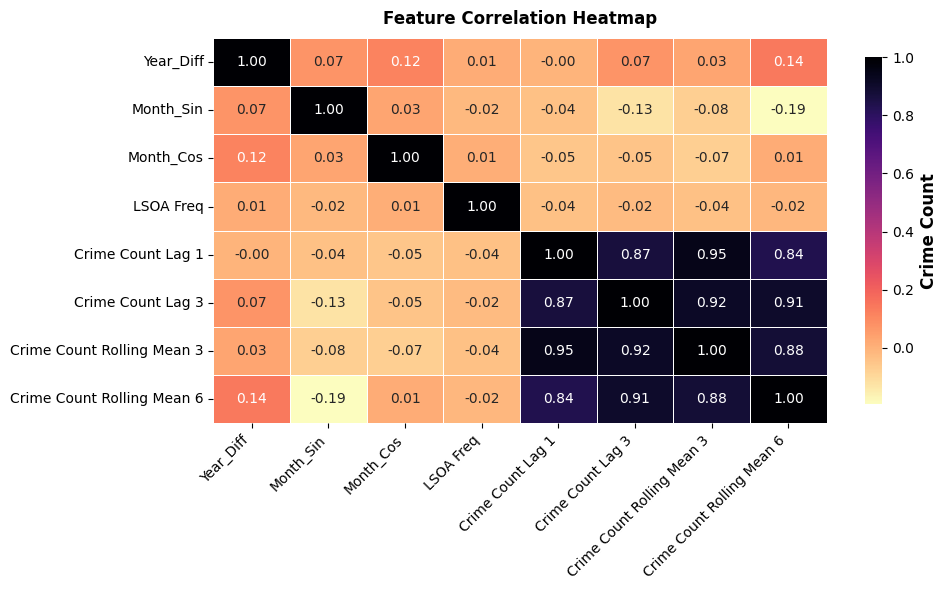

In [ ]:
# Calculate the correlation coefficients between features
corr_matrix = MLP_X_train.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="magma_r", linewidths=0.5, cbar_kws={'label': 'Crime Count', 'shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Crime Count', fontsize=12, fontweight='bold') # Include numeric annotations

plt.title("Feature Correlation Heatmap", fontsize=12, fontweight='bold',pad= 10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Hyperparameter Tuning**

In [ ]:
# The following 4 cells perform hyperparameter tuning using grid search.

# !!!This process may take up to 2 hours, so please run it with caution!!!

# According to the previous experiments, the optimal hyperparameters are as following:
# layer_options = 3, unit_options = 64, learning_rate = 0.0001, batch_size = 16
# This optimal configuration has been used in the 'Model Training' part, which can be run directly.

In [ ]:
results = []
i = 0

layer_options = [2, 3, 4, 5]
unit_options = [16, 32, 64, 128]

tf.random.set_seed(42)
np.random.seed(42)

#def mulittest(params):
for num_layers in layer_options:
    for units in unit_options:

        tf.random.set_seed(42)
        np.random.seed(42)

        model = Sequential()
        model.add(Input(shape=(X_train.shape[1],)))
        model.add(Dense(units, activation="swish",kernel_initializer="glorot_uniform"))
        for _ in range(num_layers - 1):
            model.add(Dense(units, activation="swish",kernel_initializer="glorot_uniform"))
        model.add(Dense(1))

        optimizer = Adam(learning_rate=0.0003)
        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

        early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

        history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                            epochs=100, batch_size=4, callbacks=[early_stopping], verbose=0)

        i += 1

        results.append({
            "layers": num_layers,
            "units_per_layer": units,
            "min_val_loss": np.min(history.history["val_loss"]),
        })
        print(f"\n{i} Completed: layers = {num_layers}, units = {units}")


results_df = pd.DataFrame(results)
print(results_df.sort_values("min_val_loss"))

In [ ]:
results_df_1 = results_df.copy()
heatmap_data = results_df_1.pivot(index="units_per_layer", columns="layers", values="min_val_loss")

plt.figure(figsize=(6, 4))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="magma_r", linewidths=0.5, cbar_kws={'label': 'min_val_loss','shrink': 0.9, } )

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('min_val_loss', fontsize=12, fontweight='bold')

plt.title("Gird Search for Structural Hyperparameters", fontsize=12, fontweight='bold',pad= 10)
plt.ylabel("Units per Layer", fontweight='bold', fontsize=12)
plt.xlabel("Number of Layers", fontweight='bold', fontsize=12)
plt.text(-0.2, 1, 'a', fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
plt.tight_layout()
#plt.savefig('Gird Search for Structural Hyperparameters.png', dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
best_num_layers = 3
best_units = 64

# search space
learning_rates = [1e-4, 3e-4, 5e-4, 1e-3]
batch_sizes = [4, 8, 16, 32]

tuning_results = []
i=0

tf.random.set_seed(42)
np.random.seed(42)

# 网格搜索：学习率 & 批量大小
for lr in learning_rates:
    for bs in batch_sizes:

        tf.random.set_seed(42)
        np.random.seed(42)

        model = Sequential()
        model.add(Input(shape=(X_train.shape[1],)))
        model.add(Dense(best_units, activation="swish", kernel_initializer="glorot_uniform"))
        for _ in range(best_num_layers - 1):
            model.add(Dense(best_units, activation="swish", kernel_initializer="glorot_uniform"))
        model.add(Dense(1))

        optimizer = Adam(learning_rate=lr)
        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

        early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

        history = model.fit(X_train, y_train,
                            validation_data=(X_test, y_test),
                            epochs=100,
                            batch_size=bs,
                            callbacks=[early_stopping],
                            verbose=0)
        i += 1
        tuning_results.append({
            "learning_rate": lr,
            "batch_size": bs,
            "min_val_loss": np.min(history.history["val_loss"]),
        })

        print(f"\n {i} Completed: learning_rate = {lr}, batch_size = {bs}")


results_df2 = pd.DataFrame(tuning_results)
print(results_df2.sort_values("min_val_loss"))

In [ ]:
results_df2_1 = results_df2.copy()
heatmap_data = results_df2_1.pivot(index="learning_rate", columns="batch_size", values="min_val_loss")

plt.figure(figsize=(6, 4))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="magma_r", linewidths=0.5, cbar_kws={'label': 'min_val_loss', 'shrink': 0.9,})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('min_val_loss', fontsize=12, fontweight='bold')

#plt.title("Gird Search for Optimization and Training Hyperparameters", fontsize=12, fontweight='bold',pad= 10)
plt.xlabel("Batch size", fontweight='bold', fontsize=12)
plt.ylabel("Learning rate", fontweight='bold', fontsize=12)
plt.text(-0.2, 1, 'b', fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
plt.tight_layout()
plt.savefig('Gird Search for Optimization and Training Hyperparameters.png', dpi=600, bbox_inches="tight")

plt.show()

### **Modle Training:**

In [ ]:
tf.random.set_seed(42)

MLP_model = Sequential([

    Input(shape=(MLP_X_train.shape[1],)),
    Dense(64, activation="swish"),
    Dense(64, activation="swish"),
    Dense(64, activation="swish"),
    Dense(1)
])

MLP_optimizer = Adam(learning_rate=0.0001)
MLP_model.compile(optimizer=MLP_optimizer, loss="mse", metrics=["mae"])

MLP_early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
MLP_history = MLP_model.fit(MLP_X_train, MLP_y_train, epochs=100, batch_size=16, validation_data=(MLP_X_test, MLP_y_test), callbacks=[MLP_early_stopping], verbose=1)

# give the prediction of 2024.2-12
MLP_y_val_pred_scaled = MLP_model.predict(MLP_X_val)
MLP_y_val_pred = scaler.inverse_transform(MLP_y_val_pred_scaled)

# save the result into dataframe
MLP_df_validation["Crime Count Predicted"] = MLP_y_val_pred.flatten()

Epoch 1/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.5299 - mae: 0.3867 - val_loss: 0.1843 - val_mae: 0.2787
Epoch 2/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.2856 - mae: 0.2833 - val_loss: 0.1853 - val_mae: 0.2842
Epoch 3/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2782 - mae: 0.2772 - val_loss: 0.1958 - val_mae: 0.2861
Epoch 4/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2854 - mae: 0.2789 - val_loss: 0.1699 - val_mae: 0.2633
Epoch 5/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2683 - mae: 0.2703 - val_loss: 0.1736 - val_mae: 0.2634
Epoch 6/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2747 - mae: 0.2717 - val_loss: 0.1722 - val_mae: 0.2615
Epoch 7/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2678 - mae: 0.2687 - val_loss: 0.1622 - val_mae: 0.2542
Epoch 8/100
2159/2159 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2623 - mae: 0.2658 - val_loss: 0.1679 - val_mae: 0.2599
Epoch 9/100
2159/2159 ━━━━━━

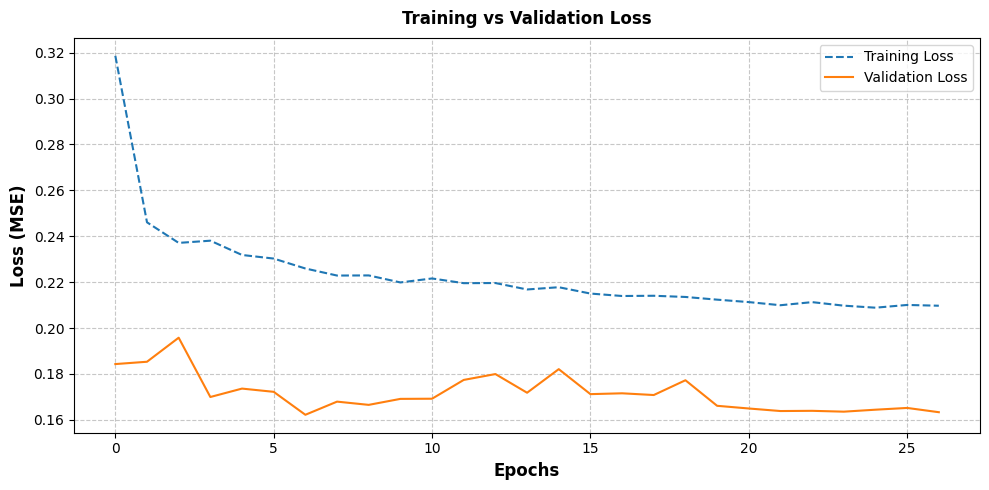

In [ ]:
# Plot of training loss and validation loss
plt.figure(figsize=(10, 5))
plt.plot(MLP_history.history['loss'], label='Training Loss', linestyle='--')
plt.plot(MLP_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss',fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
MLP_y_true = MLP_df_validation["Crime Count"].values
MLP_y_pred = MLP_df_validation["Crime Count Predicted"].values

MLP_mse = mean_squared_error(MLP_y_true, MLP_y_pred)
MLP_rmse = root_mean_squared_error(MLP_y_true, MLP_y_pred)
MLP_mae = mean_absolute_error(MLP_y_true, MLP_y_pred)
MLP_r2 = r2_score(MLP_y_true, MLP_y_pred)

print(f"MSE: {MLP_mse:.2f}")
print(f"RMSE: {MLP_rmse:.2f}")
print(f"MAE: {MLP_mae:.2f}")
print(f"R² Score: {MLP_r2:.5f}")

MSE: 17.41
RMSE: 4.17
MAE: 2.91
R² Score: 0.96055


In [ ]:
MLP_df_validation_view = MLP_df_validation[['Month', 'LSOA name', 'Crime Count','Crime Count Predicted']]
MLP_df_validation_view_all = MLP_df_validation_view.groupby("Month")[["Crime Count", "Crime Count Predicted"]].sum().reset_index()
MLP_df_validation_view_all["Crime Count Predicted"] = MLP_df_validation_view_all["Crime Count Predicted"].round().astype(int)
MLP_df_validation_view_all

,Month,Crime Count,Crime Count Predicted
0,2024-02-01,26067,27704
1,2024-03-01,28383,28618
2,2024-04-01,28495,28092
3,2024-05-01,31037,30732
4,2024-06-01,29865,30251
5,2024-07-01,31636,32423
6,2024-08-01,29180,30472
7,2024-09-01,28635,31011
8,2024-10-01,29074,29986
9,2024-11-01,26571,28477


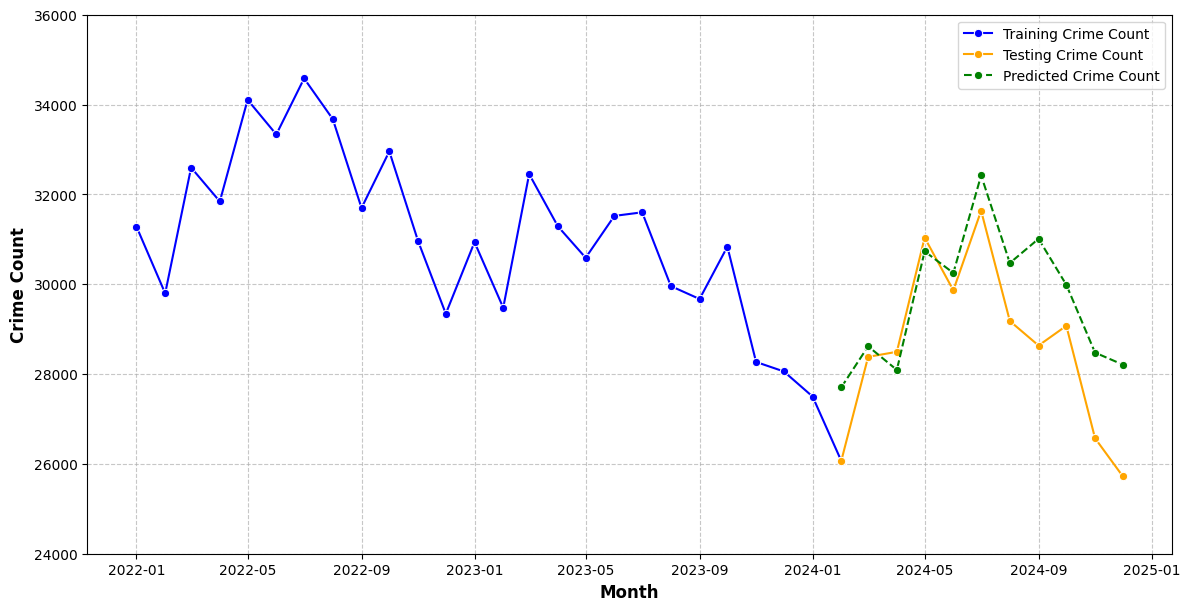

In [ ]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=df_month.iloc[:26], x='Month', y='Crime Count', marker='o', label='Training Crime Count', color='blue')
sns.lineplot(data=df_month.iloc[25:36], x='Month', y='Crime Count', marker='o', label='Testing Crime Count', color='orange')
sns.lineplot(data=MLP_df_validation_view_all, x='Month', y='Crime Count Predicted', marker='o', linestyle='--', label='Predicted Crime Count', color='green')

#plt.title('Comparison of Training, Testing and Predicted Crime Count', fontsize=12, fontweight='bold',pad= 10)
plt.xlabel('Month',fontsize=12, fontweight='bold')
plt.ylabel('Crime Count', fontsize=12, fontweight='bold')
plt.grid(linestyle='--', alpha=0.7)
plt.ylim(24000, 36000)

plt.savefig('Comparison of Training, Testing and Predicted Crime Count.png', dpi=600, bbox_inches="tight")
plt.show()

## **XGBoost(eXtreme Gradient Boosting) Model**

XGBoost is a gradient boosting model that handles complex feature interactions and missing data, making it highly effective in predicting crime counts based on spatial and temporal features.

### **Data Preparation and Feature Engineering**
We have added lag features to accomodate the seasonality in the data
Also focusing on the required columns for model creation and prediction

In [ ]:
xgboost_df = df_street_Final.copy()

# Focus on the required columns
cols = ["Crime ID", "Month", "Reported by", "Falls within", "Longitude",
        "Latitude", "Location", "LSOA code", "LSOA name", "Crime type"]
xgboost_df = xgboost_df[cols]

# Convert 'Month' to datetime (assuming format like "Jan 2022")
xgboost_df['Month'] = pd.to_datetime(xgboost_df['Month'], format='%b %Y')

# Aggregate crime counts per Month, LSOA code, and LSOA name
agg_cols = ["Month", "LSOA code", "LSOA name"]
xgboost_crime_agg = xgboost_df.groupby(agg_cols).agg({'Crime ID': 'count'}).reset_index()
xgboost_crime_agg.rename(columns={'Crime ID': 'Crime Count'}, inplace=True)

# Create basic time-based features
xgboost_crime_agg['Year'] = xgboost_crime_agg['Month'].dt.year
xgboost_crime_agg['Month_Num'] = xgboost_crime_agg['Month'].dt.month
xgboost_crime_agg['Quarter'] = xgboost_crime_agg['Month'].dt.quarter

# Add Time-Series Features (Lag & Rolling Average)
def add_time_series_features(df, group_col, target_col):
    # Sort by group and Month to ensure proper ordering
    df = df.sort_values(by=[group_col, 'Month'])
    # Create lag features (1-month and 4-month)
    df[f'{target_col}_lag_1'] = df.groupby(group_col)[target_col].shift(1)
    df[f'{target_col}_lag_4'] = df.groupby(group_col)[target_col].shift(4)
    # Create a rolling average over the last 3 months
    df[f'{target_col}_roll_avg_4'] = df.groupby(group_col)[target_col].rolling(4).mean().reset_index(0, drop=True)
    # Fill any NaN values (from shifting/rolling) with 0 or consider other imputation strategies
    df.fillna(0, inplace=True)
    return df

xgboost_crime_agg = add_time_series_features(xgboost_crime_agg, group_col='LSOA name', target_col='Crime Count')

# Sorting the data by year and month
xgboost_crime_agg = xgboost_crime_agg.sort_values(by=["Year", "Month"]).reset_index(drop=True)

### **Training and Test Split**

#### **Training Data** - The duration of the training data is from Janaury 2022 to January 2024. We have included the month of Janaury 2024 to accomodate the prediciton for the month of Janaury 2025

#### **Testing Data** - The duration of the testing data is from February 2024 to December 2024

In [ ]:
# Training data till January 2024 and testing data as last 11 months
split_date = '2024-02-01'
xgboost_train_df = xgboost_crime_agg[xgboost_crime_agg['Month'] < split_date]
xgboost_test_df = xgboost_crime_agg[xgboost_crime_agg['Month'] >= split_date]

### **Features and Target Variables**

In [ ]:
# Define features and target variable.
# We'll use the original time features plus our newly added lag and rolling average features.
features = ['LSOA code', 'LSOA name', 'Year', 'Month_Num', 'Quarter',
            'Crime Count_lag_1', 'Crime Count_lag_4', 'Crime Count_roll_avg_4']
target = 'Crime Count'

xgboost_X_train = xgboost_train_df[features]
xgboost_y_train = xgboost_train_df[target]
xgboost_X_test = xgboost_test_df[features]
xgboost_y_test = xgboost_test_df[target]

display(xgboost_train_df.tail(3))
display(xgboost_test_df.head(3))

,Month,LSOA code,LSOA name,Crime Count,Year,Month_Num,Quarter,Crime Count_lag_1,Crime Count_lag_4,Crime Count_roll_avg_4
43172,2024-01-01,E01010530,Wolverhampton 035H,60,2024,1,1,58.0,82.0,65.25
43173,2024-01-01,E01034314,Wolverhampton 035I,13,2024,1,1,20.0,27.0,18.00
43174,2024-01-01,E01034315,Wolverhampton 035J,5,2024,1,1,9.0,11.0,8.25


,Month,LSOA code,LSOA name,Crime Count,Year,Month_Num,Quarter,Crime Count_lag_1,Crime Count_lag_4,Crime Count_roll_avg_4
43175,2024-02-01,E01009417,Birmingham 001A,3,2024,2,1,1.0,4.0,3.00
43176,2024-02-01,E01009418,Birmingham 001B,4,2024,2,1,7.0,15.0,5.25
43177,2024-02-01,E01009419,Birmingham 001C,2,2024,2,1,2.0,4.0,3.75


### **Model Pipeline and Training**

In [ ]:

# Define categorical and numerical features.
categorical_features = ['LSOA code', 'LSOA name']
numerical_features = ['Year', 'Month_Num', 'Quarter', 'Crime Count_lag_1', 'Crime Count_lag_4', 'Crime Count_roll_avg_4']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# Create a pipeline with preprocessor and XGBoost regressor.
xgboost_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100))
])

# Train the model on training data.
xgboost_model_pipeline.fit(xgboost_X_train, xgboost_y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['LSOA code', 'LSOA name']),
                                                 ('num', 'passthrough',
                                                  ['Year', 'Month_Num',
                                                   'Quarter',
                                                   'Crime Count_lag_1',
                                                   'Crime Count_lag_4',
                                                   'Crime '
                                                   'Count_roll_avg_4'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, co...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

### **Model Evaluation**

#### For model evaluation, we have selected the four common metrics

- R-squared Error
- RMSE
- MAE
- MSE

In [ ]:
# Predict on the test set
xgboost_y_test_pred = xgboost_model_pipeline.predict(xgboost_X_test)

# Calculate evaluation metrics.
mse = mean_squared_error(xgboost_y_test, xgboost_y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xgboost_y_test,xgboost_y_test_pred)
r2 = r2_score(xgboost_y_test, xgboost_y_test_pred)

metric_name = ['Mean Squared Error', 'Root Mean Squared Error', 'Mean Absolute Error', f'R\u00b2']
metric_score = [mse, rmse, mae, r2]

xgboost_score_df = pd.DataFrame({'Metric': metric_name, 'Score': metric_score})
xgboost_score_df

,Metric,Score
0,Mean Squared Error,29.137808
1,Root Mean Squared Error,5.397945
2,Mean Absolute Error,3.413103
3,R²,0.933992


### **Plotting the results - Actual vs Predicted**

#### Finally we have plotted the actual vs the predicted results

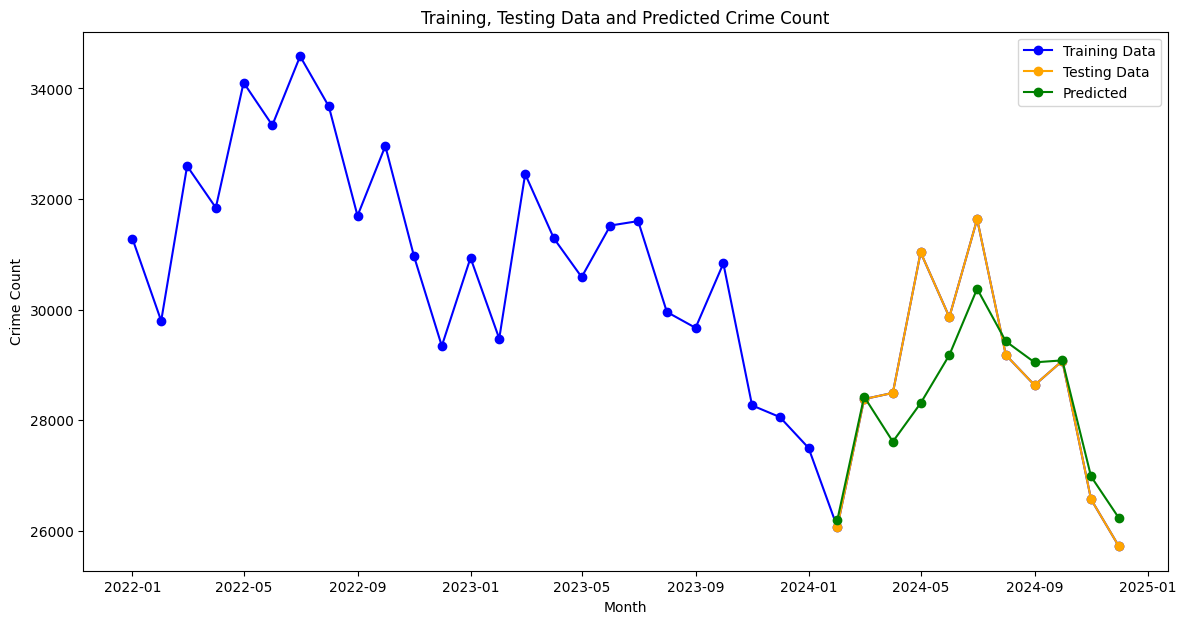

In [ ]:
# Add predictions to the test DataFrame for plotting.
xgboost_test_df = xgboost_test_df.copy()  # To avoid modifying original DataFrame.
xgboost_test_df['Predicted'] = xgboost_y_test_pred

agg_test = xgboost_test_df.groupby('Month').agg({'Crime Count': 'sum'}).reset_index()
agg_test_predicted = xgboost_test_df.groupby('Month').agg({'Predicted': 'sum'}).reset_index()
agg_actual = xgboost_crime_agg.groupby('Month').agg({'Crime Count': 'sum'}).reset_index()

plt.figure(figsize = (14,7))
plt.plot(agg_actual['Month'], agg_actual['Crime Count'], color='blue', label='Training Data', marker='o')
plt.plot(agg_test['Month'], agg_test['Crime Count'], color='orange', label='Testing Data', marker='o')
plt.plot(agg_test_predicted['Month'], agg_test_predicted['Predicted'], color='green', label='Predicted', marker='o')
plt.title("Training, Testing Data and Predicted Crime Count")
plt.legend()
plt.xlabel('Month')
plt.ylabel('Crime Count')
plt.show()

## **Ensemble Model(Random Forest & XGBoost)**

Combining Random Forest and XGBoost into an ensemble model leverages their strengths, enhancing prediction stability and accuracy. The ensemble approach reduces overfitting and improves model performance.

### **Data Preparation and Feature Engineering**

The dataset is copied to preserve the original data. Lag features (Lag 1, 2, 3) are generated using the `.shift()` function to capture historical crime patterns, while a 3-month rolling mean using `.rolling(window=3).mean()` smooths short-term fluctuations.

In [ ]:
# Copy the original DataFrame to preserve the original dataset
Ens_Crime_Count = Crime_Month_LSOA_Name.copy()

# Feature Creation: Adding Lag Features and Rolling Mean
def Ens_create_lag_features(Ens_df, Ens_lag=3):
    # Sort the data by 'LSOA code', 'LSOA name', 'Year', and 'Month_Num'
    Ens_df_sorted = Ens_df.sort_values(by=['LSOA code', 'LSOA name', 'Year', 'Month_Num'])

    # Iterate through each group defined by 'LSOA code' and 'LSOA name'
    for (lsoa_code, lsoa_name), group in Ens_df_sorted.groupby(['LSOA code', 'LSOA name']):
        # Create lag features for 'Crime Count' (e.g., lag 1, lag 2, lag 3)
        for i in range(1, Ens_lag + 1):
            Ens_df_sorted.loc[group.index, f'Ens_Crime_Count_Lag_{i}'] = group['Crime Count'].shift(i)
        # Create a 3-month rolling mean for 'Crime Count'
        Ens_df_sorted.loc[group.index, 'Ens_Crime_Rolling_Mean_3'] = group['Crime Count'].rolling(window=3).mean()

    return Ens_df_sorted

# Apply the lag and rolling mean feature creation
Ens_Crime_Count = Ens_create_lag_features(Ens_Crime_Count)
# Fill missing values generated by the lag/rolling features with 0
Ens_Crime_Count.fillna(0, inplace=True)

### **Data Splitting:**  
The data is divided into training (January 2022 to January 2024) and testing (February to December 2024) sets. This ensures the model is trained on historical data and evaluated on future data for a realistic performance assessment.

In [ ]:
# Split the data into training and testing sets based on specific date ranges
Ens_train_df = Ens_Crime_Count[(Ens_Crime_Count['Month'] >= '2022-01-01') & (Ens_Crime_Count['Month'] <= '2024-01-01')]
Ens_test_df = Ens_Crime_Count[(Ens_Crime_Count['Month'] >= '2024-02-01') & (Ens_Crime_Count['Month'] <= '2024-12-31')]

### **Features and Target variables**

The features include categorical variables (LSOA code, LSOA name) and numerical variables (Year, Month_Num, Quarter, Ens_Crime_Count_Lag_1,Ens_Crime_Count_Lag_2, Ens_Crime_Count_Lag_3, Ens_Crime_Rolling_Mean_3). The target variable is Crime Count, which the model aims to predict based on these features, with preprocessing including scaling, one-hot encoding, and PCA for dimensionality reduction.

In [ ]:
# Define the features for encoding and preprocessing
Ens_categorical_features = ['LSOA code', 'LSOA name']
Ens_numerical_features = ['Year', 'Month_Num', 'Quarter', 'Ens_Crime_Count_Lag_1', 'Ens_Crime_Count_Lag_2', 'Ens_Crime_Count_Lag_3', 'Ens_Crime_Rolling_Mean_3']

# Separate features and target for training and testing
Ens_X_train = Ens_train_df[Ens_categorical_features + Ens_numerical_features]
Ens_y_train = Ens_train_df['Crime Count']
Ens_X_test = Ens_test_df[Ens_categorical_features + Ens_numerical_features]
Ens_y_test = Ens_test_df['Crime Count']

# Set up the preprocessor: scaling for numerical features and one-hot encoding for categorical features
Ens_preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), Ens_numerical_features),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), Ens_categorical_features)])

# Apply preprocessing: fit on training data and transform both train and test sets
Ens_X_train_transformed = Ens_preprocessor.fit_transform(Ens_X_train)
Ens_X_test_transformed = Ens_preprocessor.transform(Ens_X_test)

# Apply PCA to reduce the dimensionality of the features
Ens_pca = PCA(n_components=15)  # Limiting to 15 components for efficiency
Ens_X_train_pca = Ens_pca.fit_transform(Ens_X_train_transformed)
Ens_X_test_pca = Ens_pca.transform(Ens_X_test_transformed)

### **Model Pipeline & Training**

PCA is applied for dimensionality reduction, followed by hyperparameter tuning of Random Forest and XGBoost models using randomized search. These models are then combined into an ensemble using **stacking**, with a final Linear Regression estimator for prediction.

In [ ]:
# Define hyperparameter grids for Random Forest and XGBoost models
Ens_rf_param_dist = {
    'n_estimators': [75, 150],  # Limiting the number of estimators
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

Ens_xgb_param_dist = {
    'n_estimators': [75, 150],  # Limiting the number of estimators
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# Define the models for Random Forest and XGBoost, and set them up for parallelized hyperparameter search
Ens_rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
Ens_xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Set up randomized search for hyperparameter tuning
Ens_rf_search = RandomizedSearchCV(Ens_rf_model, param_distributions=Ens_rf_param_dist, n_iter=3, cv=2, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
Ens_xgb_search = RandomizedSearchCV(Ens_xgb_model, param_distributions=Ens_xgb_param_dist, n_iter=3, cv=2, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)

# Set up a stacking model combining Random Forest and XGBoost as base models with a Linear Regression final estimator
Ens_stacking_model = StackingRegressor(
    estimators=[('rf', Ens_rf_search), ('xgb', Ens_xgb_search)],
    final_estimator=LinearRegression()  # A simple, fast final estimator
)

# Create a pipeline with the stacking model
Ens_stacking_pipeline = Pipeline(steps=[('regressor', Ens_stacking_model)])

# Train the stacking model on the training set
Ens_stacking_pipeline.fit(Ens_X_train_pca, Ens_y_train)


Pipeline(steps=[('regressor',
                 StackingRegressor(estimators=[('rf',
                                                RandomizedSearchCV(cv=2,
                                                                   estimator=RandomForestRegressor(n_jobs=-1,
                                                                                                   random_state=42),
                                                                   n_iter=3,
                                                                   n_jobs=-1,
                                                                   param_distributions={'max_depth': [10,
                                                                                                      20],
                                                                                        'min_samples_leaf': [2,
                                                                                                             5],
                                                                                        'min_samples_split': [5,
                                                                                                              10],
                                                                                        'n_estimators': [75,
                                                                                                         150]},
                                                                   random_state=42,
                                                                   scoring='neg_mean_absolute_error')),
                                               ('xgb',
                                                Random...
                                                                                          monotone_constraints=None,
                                                                                          multi_strategy=None,
                                                                                          n_estimators=None,
                                                                                          n_jobs=-1,
                                                                                          num_parallel_tree=None,
                                                                                          random_state=42, ...),
                                                                   n_iter=3,
                                                                   n_jobs=-1,
                                                                   param_distributions={'colsample_bytree': [0.8,
                                                                                                             1.0],
                                                                                        'learning_rate': [0.05,
                                                                                                          0.1],
                                                                                        'max_depth': [6,
                                                                                                      8],
                                                                                        'n_estimators': [75,
                                                                                                         150],
                                                                                        'subsample': [0.8,
                                                                                                      1.0]},
                                                                   random_state=42,
                                                                   scoring='neg_mean_absolute_error'))],
                                   final_estimator=LinearRegression()))])

### Model Evaluation

The model's performance is evaluated on the test set using **MSE**, **RMSE**, **MAE**, and **R2** metrics to assess its prediction accuracy and overall effectiveness.

In [ ]:
# Predict on the test set
Ens_y_pred = Ens_stacking_pipeline.predict(Ens_X_test_pca)

# Evaluate the model performance using different metrics
Ens_mse = mean_squared_error(Ens_y_test, Ens_y_pred)
Ens_rmse = np.sqrt(Ens_mse)
Ens_mae = mean_absolute_error(Ens_y_test, Ens_y_pred)
Ens_r2 = r2_score(Ens_y_test, Ens_y_pred)

# Print the evaluation metrics
print("Optimized results for Ensemble Models with PCA and Fine-Tuned Hyperparameters:")
print("Ensemble - Mean Squared Error (MSE):", Ens_mse)
print("Ensemble - Root Mean Squared Error (RMSE):", Ens_rmse)
print("Ensemble - Mean Absolute Error (MAE):", Ens_mae)
print("Ensemble - R2 Score:", Ens_r2)


Optimized results for Ensemble Models with PCA and Fine-Tuned Hyperparameters:
Ensemble - Mean Squared Error (MSE): 10.285370547763566
Ensemble - Root Mean Squared Error (RMSE): 3.2070813129329236
Ensemble - Mean Absolute Error (MAE): 1.6038479521216882
Ensemble - R2 Score: 0.9766997358882094


### **Actual vs Predicted Crime Counts Visualization**

This code evaluates the ensemble crime prediction model by comparing actual and predicted crime counts for different LSOAs. It includes:

- **Data Preparation**: Copies datasets, adds predicted crime counts, and formats the 'Month' column.
- **Top 5 LSOA Selection**: Identifies the top 5 LSOAs with the highest total crime counts.
- **Visualizations**: Plots actual vs predicted crime counts for the top 5 LSOAs and the total crime counts over time.
- **Comparison**: Compares actual vs predicted crime counts across the full dataset and training set to assess model performance.

These visualizations offer insights into the model's accuracy and performance over time.

Top 5 LSOA: [('E01033620', 'Birmingham 138A'), ('E01010368', 'Walsall 030A'), ('E01033615', 'Birmingham 135C'), ('E01033617', 'Birmingham 050F'), ('E01034743', 'Coventry 031E')]


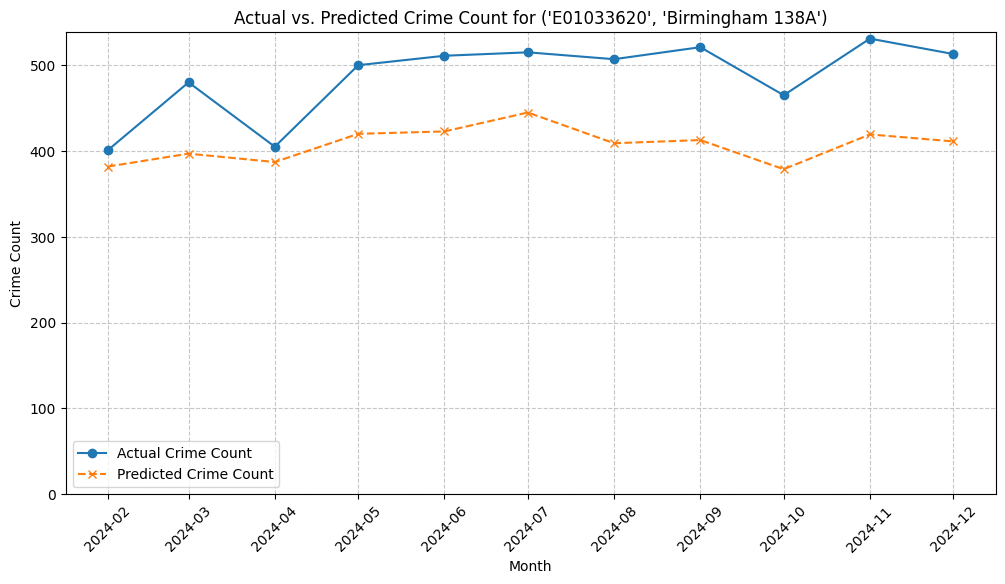

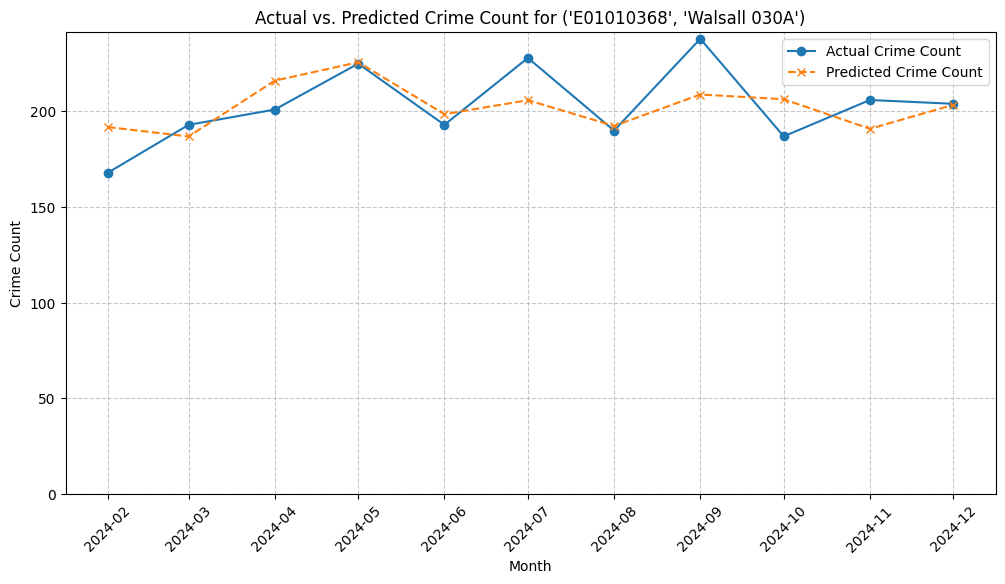

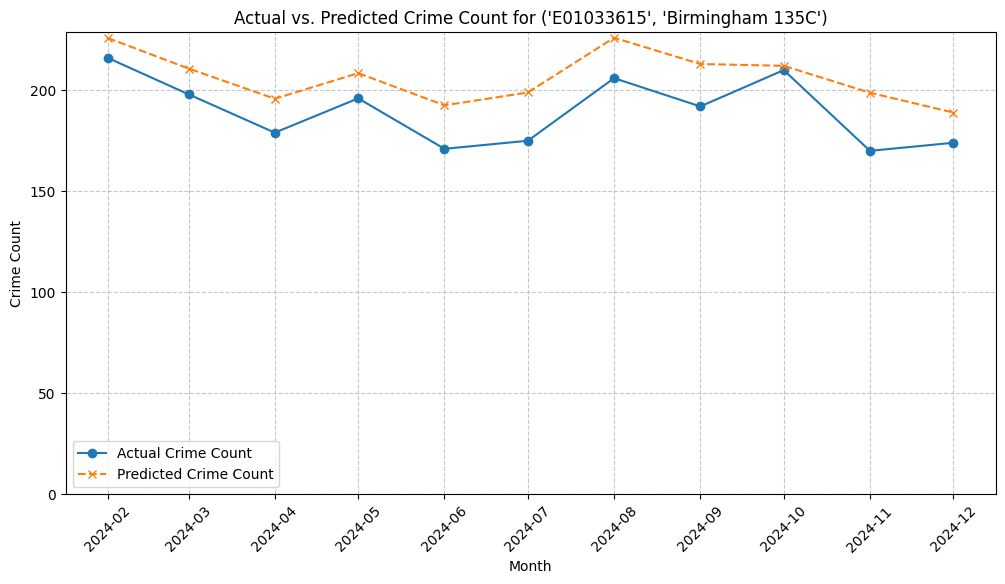

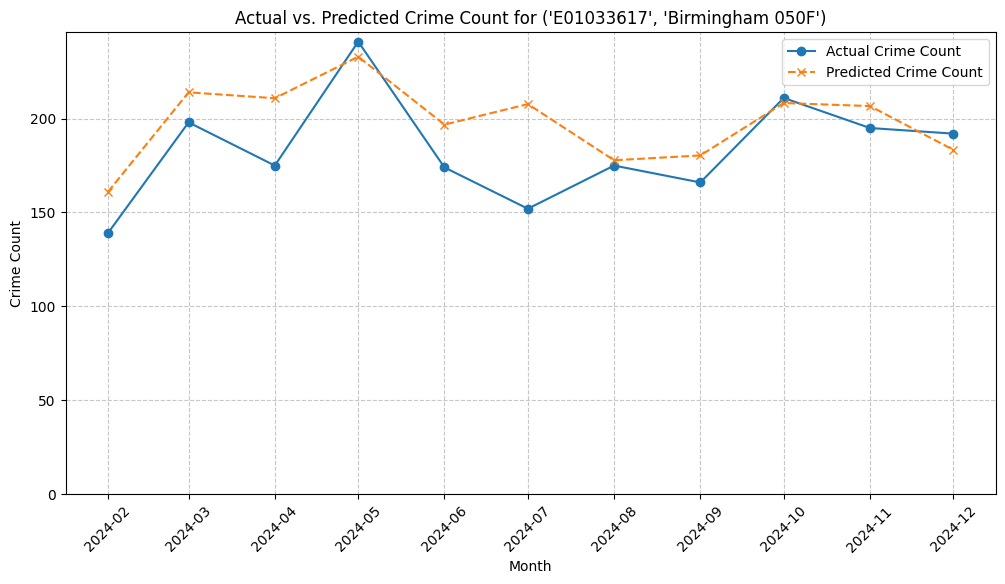

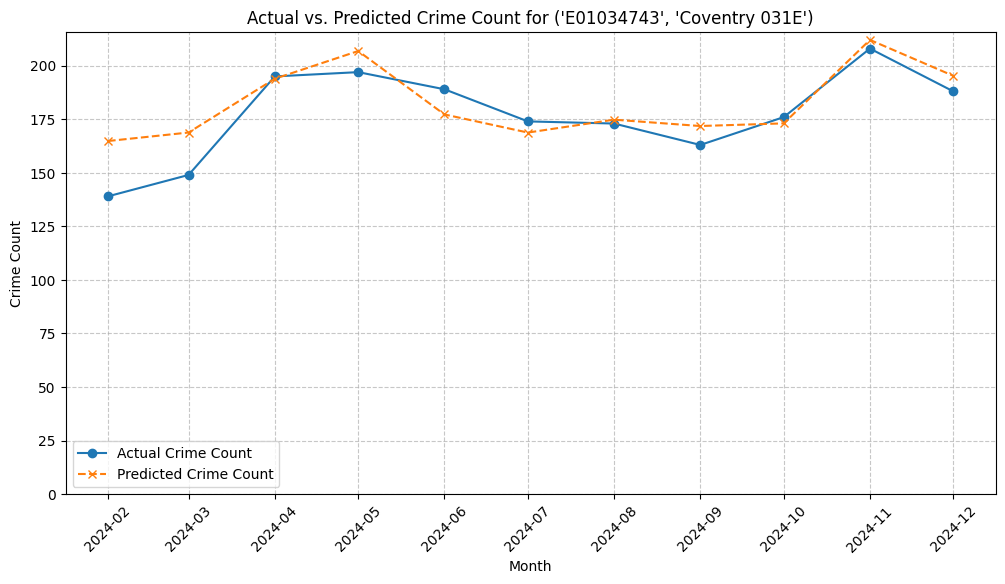

In [ ]:
# Create a copy of the test set data for comparison
Ens_X_test_copy = Ens_X_test.copy()

# Add predicted and actual crime counts to the test set copy for comparison
Ens_X_test_copy['Predicted Crime Count'] = Ens_y_pred
Ens_X_test_copy['Actual Crime Count'] = Ens_y_test

# Create 'Month' column based on 'Year' and 'Month_Num' for the test set
Ens_X_test_copy['Month'] = pd.to_datetime(Ens_X_test_copy['Year'].astype(str) + '-' + Ens_X_test_copy['Month_Num'].astype(str), format='%Y-%m')

# Reset index for the test set copy for consistency
Ens_X_test_copy.reset_index(drop=True, inplace=True)

# Create a copy of the training set data for comparison
Ens_X_train_copy = Ens_X_train.copy()

# Add actual crime counts to the training set copy for comparison
Ens_X_train_copy['Actual Crime Count'] = Ens_y_train

# Create 'Month' column based on 'Year' and 'Month_Num' for the training set
Ens_X_train_copy['Month'] = pd.to_datetime(Ens_X_train_copy['Year'].astype(str) + '-' + Ens_X_train_copy['Month_Num'].astype(str), format='%Y-%m')

# Reset index for the training set copy for consistency
Ens_X_train_copy.reset_index(drop=True, inplace=True)
Ens_X_train_copy.head()

# ----- Step 5: Identify Top 5 LSOA by Total Crime Count (Test Set) -----
# Sum up the total crime counts per LSOA from the test set
Ens_lsoa_totals = Ens_X_test_copy.groupby(["LSOA code","LSOA name"])["Actual Crime Count"].sum()

# Sort by crime count and select the top 5 LSOA with the highest crime counts
Ens_top5_lsoa = Ens_lsoa_totals.sort_values(ascending=False).head(5).index.tolist()
print("Top 5 LSOA:", Ens_top5_lsoa)

# Extract the LSOA codes and names from the list of tuples
Ens_top5_lsoa_codes = [item[0] for item in Ens_top5_lsoa]
Ens_top5_lsoa_names = [item[1] for item in Ens_top5_lsoa]

# Filter the data to include only the rows corresponding to the top 5 LSOAs
Ens_plot_data = Ens_X_test_copy[
    Ens_X_test_copy["LSOA code"].isin(Ens_top5_lsoa_codes) |
    Ens_X_test_copy["LSOA name"].isin(Ens_top5_lsoa_names)
]

# ----- Step 6: Plot Actual vs. Predicted for Each Top LSOA -----
# Loop through each of the top 5 LSOAs to plot actual vs predicted crime counts
for Ens_lsoa in Ens_top5_lsoa:
    lsoa_code, lsoa_name = Ens_lsoa  # Unpack the tuple into two variables

    # Filter the plot data for the current LSOA
    Ens_lsoa_data = Ens_plot_data[
        (Ens_plot_data["LSOA code"] == lsoa_code) & (Ens_plot_data["LSOA name"] == lsoa_name)
    ].sort_values(by="Month")

    # Plot actual and predicted crime counts for the LSOA
    plt.figure(figsize=(12, 6))
    plt.plot(Ens_lsoa_data["Month"], Ens_lsoa_data["Actual Crime Count"], label="Actual Crime Count", marker="o")
    plt.plot(Ens_lsoa_data["Month"], Ens_lsoa_data["Predicted Crime Count"], label="Predicted Crime Count", marker="x", linestyle="--")
    plt.xlabel("Month")
    plt.ylabel("Crime Count")
    plt.title(f"Actual vs. Predicted Crime Count for {Ens_lsoa}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(linestyle='--', alpha=0.7)
    plt.ylim(0,)
    plt.show()

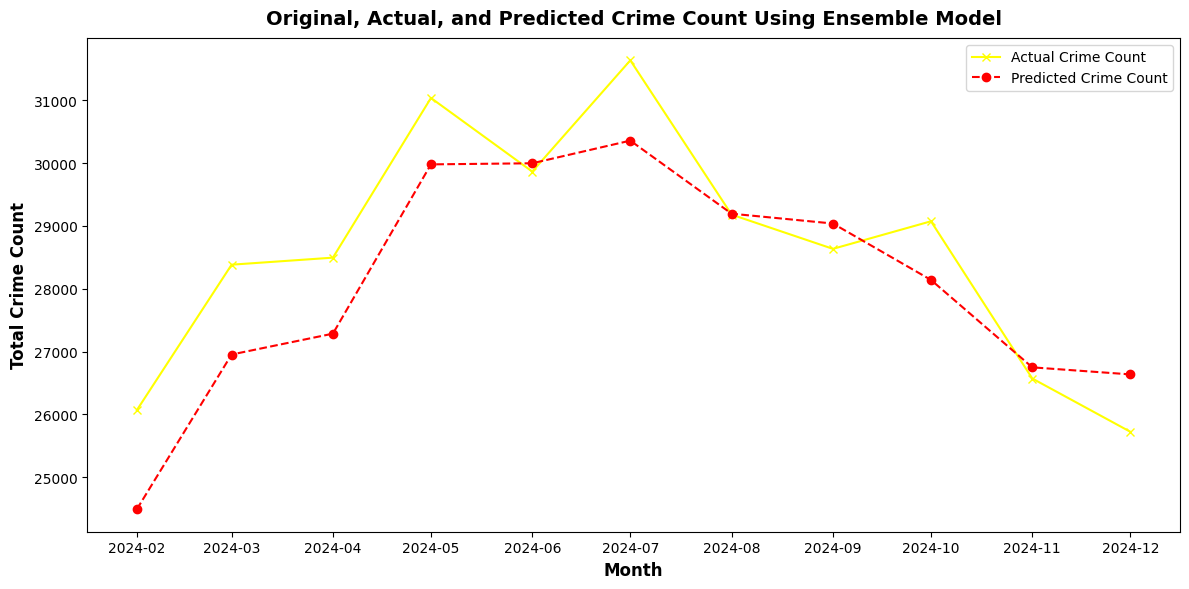

In [ ]:
# Aggregate the actual crime count per month from the test set
Ens_monthly_actual_crime_count = Ens_X_test_copy.groupby('Month')['Actual Crime Count'].sum().reset_index()

# Aggregate the predicted crime count per month from the test set
Ens_monthly_predicted_crime_count = Ens_X_test_copy.groupby('Month')['Predicted Crime Count'].sum().reset_index()

# Plot Original, Actual, and Predicted Crime Count Over Time
plt.figure(figsize=(12, 6))

# Plot actual crime count (test set)
plt.plot(Ens_monthly_actual_crime_count['Month'], Ens_monthly_actual_crime_count['Actual Crime Count'],
         marker='x', color='yellow', label='Actual Crime Count')

# Plot predicted crime count (model output)
plt.plot(Ens_monthly_predicted_crime_count['Month'], Ens_monthly_predicted_crime_count['Predicted Crime Count'],
         marker='o', linestyle='--', color='red', label='Predicted Crime Count')

# Titles, labels, and legend
plt.title('Original, Actual, and Predicted Crime Count Using Ensemble Model', fontsize=14, fontweight='bold',pad=10)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Crime Count', fontsize=12, fontweight='bold')
plt.legend()

# Display the plot with optimized layout
plt.tight_layout()
plt.show()


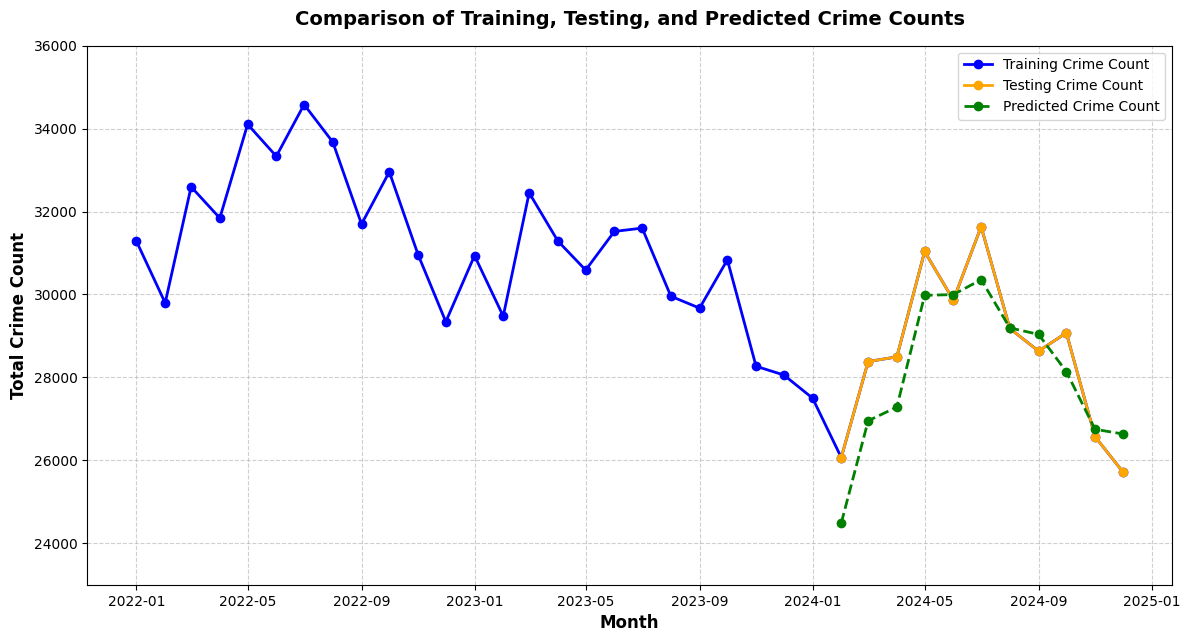

In [ ]:
# Aggregate original crime counts by month from the full dataset
Ens_monthly_crime_original = Ens_Crime_Count.groupby('Month')['Crime Count'].sum().reset_index()

# Aggregate actual crime counts by month from the training set
Ens_monthly_crime_train = Ens_X_train_copy.groupby('Month')['Actual Crime Count'].sum().reset_index()

# 📊 Plot Original, Actual, and Predicted Crime Count Over Time
plt.figure(figsize=(14, 7))

# Plot original crime count (ground truth from the full dataset)
plt.plot(Ens_monthly_crime_original['Month'], Ens_monthly_crime_original['Crime Count'],
         marker='o', color='blue', linewidth=2, label='Training Crime Count')

# Plot actual crime count (test set)
plt.plot(Ens_monthly_actual_crime_count['Month'], Ens_monthly_actual_crime_count['Actual Crime Count'],
         marker='o', color='orange', linewidth=2, label='Testing Crime Count')

# Plot predicted crime count (model output)
plt.plot(Ens_monthly_predicted_crime_count['Month'], Ens_monthly_predicted_crime_count['Predicted Crime Count'],
         marker='o', linestyle = '--', color='green', linewidth=2, label='Predicted Crime Count')

# Formatting for better readability
plt.title('Comparison of Training, Testing, and Predicted Crime Counts', fontsize=14, fontweight='bold', pad= 15)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Crime Count', fontsize=12, fontweight='bold')
plt.ylim(23000,36000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()


# **Future Prediction based on Trained Model**

**Model Performance Comparison & Rationale for Choosing the Ensemble Model**

We evaluated four models for crime prediction: **Prophet**, **MLP**, **XGBoost**, and an **Ensemble Model**. The models were assessed based on key evaluation metrics: **MAE** (Mean Absolute Error), **MSE** (Mean Squared Error), **RMSE** (Root Mean Squared Error), and **R² Score**.

| Model          | MAE    |  RMSE   | R² Score |
|----------------|--------|--------|----------|
| **Prophet**    |  2.65 |  3.54 | 84.00%     |
| **MLP**        |  2.91 |  4.17 | 96.05%     |
| **XGBoost**    |  3.41 |  5.39 | 93.39%     |
| **Ensemble**   |  1.60 |  3.20 | 97.66%     |

## **Key Insights from the Comparison:**

The **Ensemble model** delivered the best performance across all metrics:
- It achieved the highest **R-squared value of 97.66%**, meaning it explains the most variance in our data.
- It also had the **lowest Mean Absolute Error (1.60)**, indicating minimal deviation between the predicted and actual values.
- Additionally, the **Root Mean Squared Error (3.20)** was the lowest among all models, further confirming its robustness.


Given these exceptional results, the **Ensemble model** is clearly the best choice for our project. It outperforms the individual models in terms of accuracy and error minimization, making it the most reliable model for crime prediction moving forward.

### **January 2025 Prediction**

Following code predicts the crime count for January 2025 across different LSOAs by using historical crime data from the last three months of 2024, creating lag features, and applying a pre-trained machine learning model with PCA for dimensionality reduction. The results are aggregated by month and LSOA for future crime forecasting.

In [ ]:
# Ensure Month is in 'YYYY-MM' format
Ens_X_test_copy['Month'] = pd.to_datetime(Ens_X_test_copy['Month']).dt.strftime('%Y-%m')

# Extract unique LSOA codes and names from the test data
Ens_unique_lsoa_info = Ens_X_test_copy[['LSOA code', 'LSOA name']].drop_duplicates()

# Get the last 3 months of 2024 actual crime data for lag feature initialization
Ens_last_3_months_data_Jan = Ens_X_test_copy[Ens_X_test_copy['Month'].isin(['2024-10', '2024-11', '2024-12'])][['LSOA code', 'LSOA name','Month', 'Actual Crime Count']]
Ens_last_3_months_data_Jan = Ens_last_3_months_data_Jan.pivot(index=['LSOA code','LSOA name'], columns='Month', values='Actual Crime Count').fillna(0)

# Ensure expected columns exist before renaming
if Ens_last_3_months_data_Jan.shape[1] == 3:
    Ens_last_3_months_data_Jan.columns = ['Crime_Count_Oct_2024', 'Crime_Count_Nov_2024', 'Crime_Count_Dec_2024']
else:
    print("Warning: Ens_last_3_months_data_Jan has unexpected shape:", Ens_last_3_months_data_Jan.shape)

# Create an empty DataFrame for storing all LSOAs future predictions (for January 2025)
Ens_future_predictions_Jan = pd.DataFrame()

# Loop through all unique LSOA combinations to predict future crime
for _, row in Ens_unique_lsoa_info.iterrows():
    lsoa_code = row['LSOA code']
    lsoa_name = row['LSOA name']

    # Create a DataFrame for January 2025 prediction for this specific LSOA
    Ens_future_df_Jan = pd.DataFrame({'Year': [2025], 'Month_Num': [1]})
    Ens_future_df_Jan['Quarter'] = [1]  # January is in Quarter 1
    Ens_future_df_Jan['LSOA code'] = lsoa_code
    Ens_future_df_Jan['LSOA name'] = lsoa_name

    # Get last 3 months actual crime data for lag features
    Ens_last_data_Jan = Ens_last_3_months_data_Jan.loc[lsoa_code,lsoa_name] if (lsoa_code,lsoa_name) in Ens_last_3_months_data_Jan.index else None
    if Ens_last_data_Jan is not None:
        crime_lag_1 = Ens_last_data_Jan['Crime_Count_Dec_2024']
        crime_lag_2 = Ens_last_data_Jan['Crime_Count_Nov_2024']
        crime_lag_3 = Ens_last_data_Jan['Crime_Count_Oct_2024']
        rolling_mean_3 = Ens_last_data_Jan.mean()  # Use all three months to compute rolling mean
    else:
        crime_lag_1 = crime_lag_2 = crime_lag_3 = rolling_mean_3 = 0  # Default to 0 if no data

    # Add lag features and rolling mean to the future DataFrame for January 2025
    Ens_future_df_Jan['Ens_Crime_Count_Lag_1'] = crime_lag_1
    Ens_future_df_Jan['Ens_Crime_Count_Lag_2'] = crime_lag_2
    Ens_future_df_Jan['Ens_Crime_Count_Lag_3'] = crime_lag_3
    Ens_future_df_Jan['Ens_Crime_Rolling_Mean_3'] = rolling_mean_3

    # Select features required for prediction
    Ens_X_future_Jan = Ens_future_df_Jan[['Year', 'Month_Num', 'Quarter', 'Ens_Crime_Count_Lag_1', 'Ens_Crime_Count_Lag_2', 'Ens_Crime_Count_Lag_3', 'Ens_Crime_Rolling_Mean_3', 'LSOA code', 'LSOA name']]

    # Apply preprocessing (OneHotEncoding & Scaling)
    Ens_X_future_Jan_transformed = Ens_preprocessor.transform(Ens_X_future_Jan)

    # Apply PCA for dimensionality reduction
    Ens_X_future_Jan_pca = Ens_pca.transform(Ens_X_future_Jan_transformed)

    # Predict the crime count for January 2025 using the trained stacking model
    Ens_predicted_crime_count_Jan = Ens_stacking_pipeline.predict(Ens_X_future_Jan_pca)

    # Store the prediction in the DataFrame
    Ens_future_df_Jan['Predicted Crime Count'] = Ens_predicted_crime_count_Jan

    # Append the prediction for this LSOA to the result DataFrame
    Ens_future_predictions_Jan = pd.concat([Ens_future_predictions_Jan, Ens_future_df_Jan], ignore_index=True)

# Display predictions for January 2025
Ens_future_predictions_Jan['Month'] = pd.to_datetime(Ens_future_predictions_Jan['Year'].astype(str) + '-' + Ens_future_predictions_Jan['Month_Num'].astype(str), format='%Y-%m')

# Group predictions by month, LSOA code, and LSOA name
Ens_lsoa_tot_Jan = Ens_future_predictions_Jan.groupby(['Month','LSOA code','LSOA name'])['Predicted Crime Count'].sum().reset_index()

Ens_lsoa_tot_Jan.head(5)

,Month,LSOA code,LSOA name,Predicted Crime Count
0,2025-01-01,E01008881,Birmingham 067A,22.004993
1,2025-01-01,E01008882,Birmingham 066A,10.854922
2,2025-01-01,E01008883,Birmingham 078A,11.138428
3,2025-01-01,E01008884,Birmingham 078B,46.025180
4,2025-01-01,E01008885,Birmingham 076A,7.289252


### **February 2025 Prediction**

The code processes crime data for February 2025 by initializing lag features from the last 3 months, applying preprocessing and PCA, and using a stacking model to predict future crime counts. It then aggregates the predictions by LSOA and month.

In [ ]:
# Ensure the Month column is in datetime format
Ens_X_test_copy['Month'] = pd.to_datetime(Ens_X_test_copy['Month'])
Ens_future_predictions_Jan['Month'] = pd.to_datetime(Ens_future_predictions_Jan['Month'])

# Get last 3 months data for lag initialization (February 2025)
Ens_last_3_months_data_Feb1 = Ens_X_test_copy[Ens_X_test_copy['Month'].isin(pd.to_datetime(['2024-11', '2024-12']))][['LSOA code', 'LSOA name','Month', 'Actual Crime Count']]
Ens_last_3_months_data_Feb2 = Ens_future_predictions_Jan[Ens_future_predictions_Jan['Month'].isin(pd.to_datetime(['2025-01']))][['LSOA code', 'LSOA name','Month', 'Predicted Crime Count']]

# Rename column for consistency in the combined dataset
Ens_last_3_months_data_Feb2 = Ens_last_3_months_data_Feb2.rename(columns={'Predicted Crime Count': 'Actual Crime Count'})

# Combine the DataFrames to include data for February
Ens_last_3_months_data_Feb = pd.concat([Ens_last_3_months_data_Feb1, Ens_last_3_months_data_Feb2], ignore_index=True)
Ens_last_3_months_data_Feb = Ens_last_3_months_data_Feb.pivot(index=['LSOA code','LSOA name'], columns='Month', values='Actual Crime Count').fillna(0)

# Ensure expected columns exist before renaming
if Ens_last_3_months_data_Feb.shape[1] == 3:
    Ens_last_3_months_data_Feb.columns = ['Crime_Count_Nov_2024', 'Crime_Count_Dec_2024','Crime_Count_Jan_2025']
else:
    print("Warning: Ens_last_3_months_data_Feb has unexpected shape:", Ens_last_3_months_data_Feb.shape)

# Create an empty DataFrame for storing all LSOAs future predictions (for February 2025)
Ens_future_predictions_Feb = pd.DataFrame()

# Loop through all unique LSOA combinations to predict future crime for February 2025
for _, row in Ens_unique_lsoa_info.iterrows():
    lsoa_code = row['LSOA code']
    lsoa_name = row['LSOA name']

    # Create a DataFrame for February 2025 prediction for this specific LSOA
    Ens_future_df_Feb = pd.DataFrame({'Year': [2025], 'Month_Num': [2]})
    Ens_future_df_Feb['Quarter'] = [1]  # February is in Quarter 1
    Ens_future_df_Feb['LSOA code'] = lsoa_code
    Ens_future_df_Feb['LSOA name'] = lsoa_name

    # Get last 3 months actual crime data for lag features
    Ens_last_data_Feb = Ens_last_3_months_data_Feb.loc[lsoa_code,lsoa_name] if (lsoa_code,lsoa_name) in Ens_last_3_months_data_Feb.index else None
    if Ens_last_data_Feb is not None:
        crime_lag_1 = Ens_last_data_Feb['Crime_Count_Jan_2025']
        crime_lag_2 = Ens_last_data_Feb['Crime_Count_Dec_2024']
        crime_lag_3 = Ens_last_data_Feb['Crime_Count_Nov_2024']
        rolling_mean_3 = Ens_last_data_Feb.mean()  # Use all three months to compute rolling mean
    else:
        crime_lag_1 = crime_lag_2 = crime_lag_3 = rolling_mean_3 = 0  # Default to 0 if no data

    # Add lag features and rolling mean to the future DataFrame for February 2025
    Ens_future_df_Feb['Ens_Crime_Count_Lag_1'] = crime_lag_1
    Ens_future_df_Feb['Ens_Crime_Count_Lag_2'] = crime_lag_2
    Ens_future_df_Feb['Ens_Crime_Count_Lag_3'] = crime_lag_3
    Ens_future_df_Feb['Ens_Crime_Rolling_Mean_3'] = rolling_mean_3

    # Select features required for prediction
    Ens_X_future_Feb = Ens_future_df_Feb[['Year', 'Month_Num', 'Quarter', 'Ens_Crime_Count_Lag_1', 'Ens_Crime_Count_Lag_2', 'Ens_Crime_Count_Lag_3', 'Ens_Crime_Rolling_Mean_3', 'LSOA code', 'LSOA name']]

    # Apply preprocessing (OneHotEncoding & Scaling)
    Ens_X_future_Feb_transformed = Ens_preprocessor.transform(Ens_X_future_Feb)

    # Apply PCA for dimensionality reduction
    Ens_X_future_Feb_pca = Ens_pca.transform(Ens_X_future_Feb_transformed)

    # Predict the crime count for February 2025 using the trained stacking model
    Ens_predicted_crime_count_Feb = Ens_stacking_pipeline.predict(Ens_X_future_Feb_pca)

    # Store the prediction in the DataFrame
    Ens_future_df_Feb['Predicted Crime Count'] = Ens_predicted_crime_count_Feb

    # Append the prediction for this LSOA to the result DataFrame
    Ens_future_predictions_Feb = pd.concat([Ens_future_predictions_Feb, Ens_future_df_Feb], ignore_index=True)

# Display predictions for February 2025
Ens_future_predictions_Feb['Month'] = pd.to_datetime(Ens_future_predictions_Feb['Year'].astype(str) + '-' + Ens_future_predictions_Feb['Month_Num'].astype(str), format='%Y-%m')

# Group predictions by month, LSOA code, and LSOA name
Ens_lsoa_tot_Feb = Ens_future_predictions_Feb.groupby(['Month','LSOA code','LSOA name'])['Predicted Crime Count'].sum().reset_index()

Ens_lsoa_tot_Feb.head(5)

,Month,LSOA code,LSOA name,Predicted Crime Count
0,2025-02-01,E01008881,Birmingham 067A,30.638535
1,2025-02-01,E01008882,Birmingham 066A,13.748082
2,2025-02-01,E01008883,Birmingham 078A,14.178602
3,2025-02-01,E01008884,Birmingham 078B,23.204987
4,2025-02-01,E01008885,Birmingham 076A,4.497523


### **March 2025 Prediction**

The code prepares and processes crime data for March 2025 by collecting the last three months of data for lag feature initialization, combining actual and predicted crime counts, and using a trained model to predict future crime counts. It then aggregates the results by LSOA and month.

In [ ]:
# Get last 3 months of data for lag initialization (March 2025)
Ens_last_3_months_data_Mar1 = Ens_X_test_copy[Ens_X_test_copy['Month'].isin(pd.to_datetime(['2024-12']))][['LSOA code', 'LSOA name','Month', 'Actual Crime Count']]
Ens_last_3_months_data_Mar2 = Ens_future_predictions_Jan[Ens_future_predictions_Jan['Month'].isin(pd.to_datetime(['2025-01']))][['LSOA code', 'LSOA name','Month', 'Predicted Crime Count']]

# Rename column for consistency in the combined dataset
Ens_last_3_months_data_Mar2 = Ens_last_3_months_data_Mar2.rename(columns={'Predicted Crime Count': 'Actual Crime Count'})
Ens_last_3_months_data_Mar3 = Ens_future_predictions_Feb[Ens_future_predictions_Feb['Month'].isin(pd.to_datetime(['2025-02']))][['LSOA code', 'LSOA name','Month', 'Predicted Crime Count']]

# Rename column for consistency in the combined dataset
Ens_last_3_months_data_Mar3 = Ens_last_3_months_data_Mar3.rename(columns={'Predicted Crime Count': 'Actual Crime Count'})

# Combine the DataFrames to include data for March
Ens_last_3_months_data_Mar = pd.concat([Ens_last_3_months_data_Mar1, Ens_last_3_months_data_Mar2,Ens_last_3_months_data_Mar3], ignore_index=True)
Ens_last_3_months_data_Mar = Ens_last_3_months_data_Mar.pivot(index=['LSOA code','LSOA name'], columns='Month', values='Actual Crime Count').fillna(0)

# Ensure expected columns exist before renaming
if Ens_last_3_months_data_Mar.shape[1] == 3:
    Ens_last_3_months_data_Mar.columns = ['Crime_Count_Dec_2024', 'Crime_Count_Jan_2025','Crime_Count_Feb_2025']
else:
    print("Warning: Ens_last_3_months_data_Mar has unexpected shape:", Ens_last_3_months_data_Mar.shape)

# Create an empty DataFrame for storing all LSOAs future predictions (for March 2025)
Ens_future_predictions_Mar = pd.DataFrame()

# Loop through all unique LSOA combinations to predict future crime for March 2025
for _, row in Ens_unique_lsoa_info.iterrows():
    lsoa_code = row['LSOA code']
    lsoa_name = row['LSOA name']

    # Create a DataFrame for March 2025 prediction for this specific LSOA
    Ens_future_df_Mar = pd.DataFrame({'Year': [2025], 'Month_Num': [3]})
    Ens_future_df_Mar['Quarter'] = [1]  # March is in Quarter 1
    Ens_future_df_Mar['LSOA code'] = lsoa_code
    Ens_future_df_Mar['LSOA name'] = lsoa_name

    # Get last 3 months actual crime data for lag features
    Ens_last_data_Mar = Ens_last_3_months_data_Mar.loc[lsoa_code, lsoa_name] if (lsoa_code, lsoa_name) in Ens_last_3_months_data_Mar.index else None
    if Ens_last_data_Mar is not None:
        crime_lag_1 = Ens_last_data_Mar['Crime_Count_Feb_2025']
        crime_lag_2 = Ens_last_data_Mar['Crime_Count_Jan_2025']
        crime_lag_3 = Ens_last_data_Mar['Crime_Count_Dec_2024']
        rolling_mean_3 = Ens_last_data_Mar.mean()  # Use all three months to compute rolling mean
    else:
        crime_lag_1 = crime_lag_2 = crime_lag_3 = rolling_mean_3 = 0  # Default to 0 if no data

    # Add lag features and rolling mean to the future DataFrame for March 2025
    Ens_future_df_Mar['Ens_Crime_Count_Lag_1'] = crime_lag_1
    Ens_future_df_Mar['Ens_Crime_Count_Lag_2'] = crime_lag_2
    Ens_future_df_Mar['Ens_Crime_Count_Lag_3'] = crime_lag_3
    Ens_future_df_Mar['Ens_Crime_Rolling_Mean_3'] = rolling_mean_3

    # Select features required for prediction
    Ens_X_future_Mar = Ens_future_df_Mar[['Year', 'Month_Num', 'Quarter', 'Ens_Crime_Count_Lag_1', 'Ens_Crime_Count_Lag_2', 'Ens_Crime_Count_Lag_3', 'Ens_Crime_Rolling_Mean_3', 'LSOA code', 'LSOA name']]

    # Apply preprocessing (OneHotEncoding & Scaling)
    Ens_X_future_Mar_transformed = Ens_preprocessor.transform(Ens_X_future_Mar)

    # Apply PCA for dimensionality reduction
    Ens_X_future_Mar_pca = Ens_pca.transform(Ens_X_future_Mar_transformed)

    # Predict the crime count for March 2025 using the trained stacking model
    Ens_predicted_crime_count_Mar = Ens_stacking_pipeline.predict(Ens_X_future_Mar_pca)

    # Store the prediction in the DataFrame
    Ens_future_df_Mar['Predicted Crime Count'] = Ens_predicted_crime_count_Mar

    # Append the prediction for this LSOA to the result DataFrame
    Ens_future_predictions_Mar = pd.concat([Ens_future_predictions_Mar, Ens_future_df_Mar], ignore_index=True)

# Display predictions for March 2025
Ens_future_predictions_Mar['Month'] = pd.to_datetime(Ens_future_predictions_Mar['Year'].astype(str) + '-' + Ens_future_predictions_Mar['Month_Num'].astype(str), format='%Y-%m')

# Group predictions by month, LSOA code, and LSOA name
Ens_lsoa_tot_Mar = Ens_future_predictions_Mar.groupby(['Month', 'LSOA code', 'LSOA name'])['Predicted Crime Count'].sum().reset_index()

Ens_lsoa_tot_Mar.head(5)

,Month,LSOA code,LSOA name,Predicted Crime Count
0,2025-03-01,E01008881,Birmingham 067A,23.583368
1,2025-03-01,E01008882,Birmingham 066A,13.078923
2,2025-03-01,E01008883,Birmingham 078A,13.792586
3,2025-03-01,E01008884,Birmingham 078B,35.953237
4,2025-03-01,E01008885,Birmingham 076A,8.027812


## **Top 10 LSOAs and Predicted Crime Counts (Jan - Mar 2025)**

* **Combine Predictions:** Merges the crime predictions for January, February, and March 2025 into a single DataFrame.

* **Top 10 LSOAs:** Identifies the top 10 LSOAs with the highest predicted crime counts for each month.

* **Visualization:** Creates bar plots for each month showing the top 10 LSOAs, with LSOA names on the x-axis and predicted crime counts on the y-axis. The plot layout is adjusted for clarity.


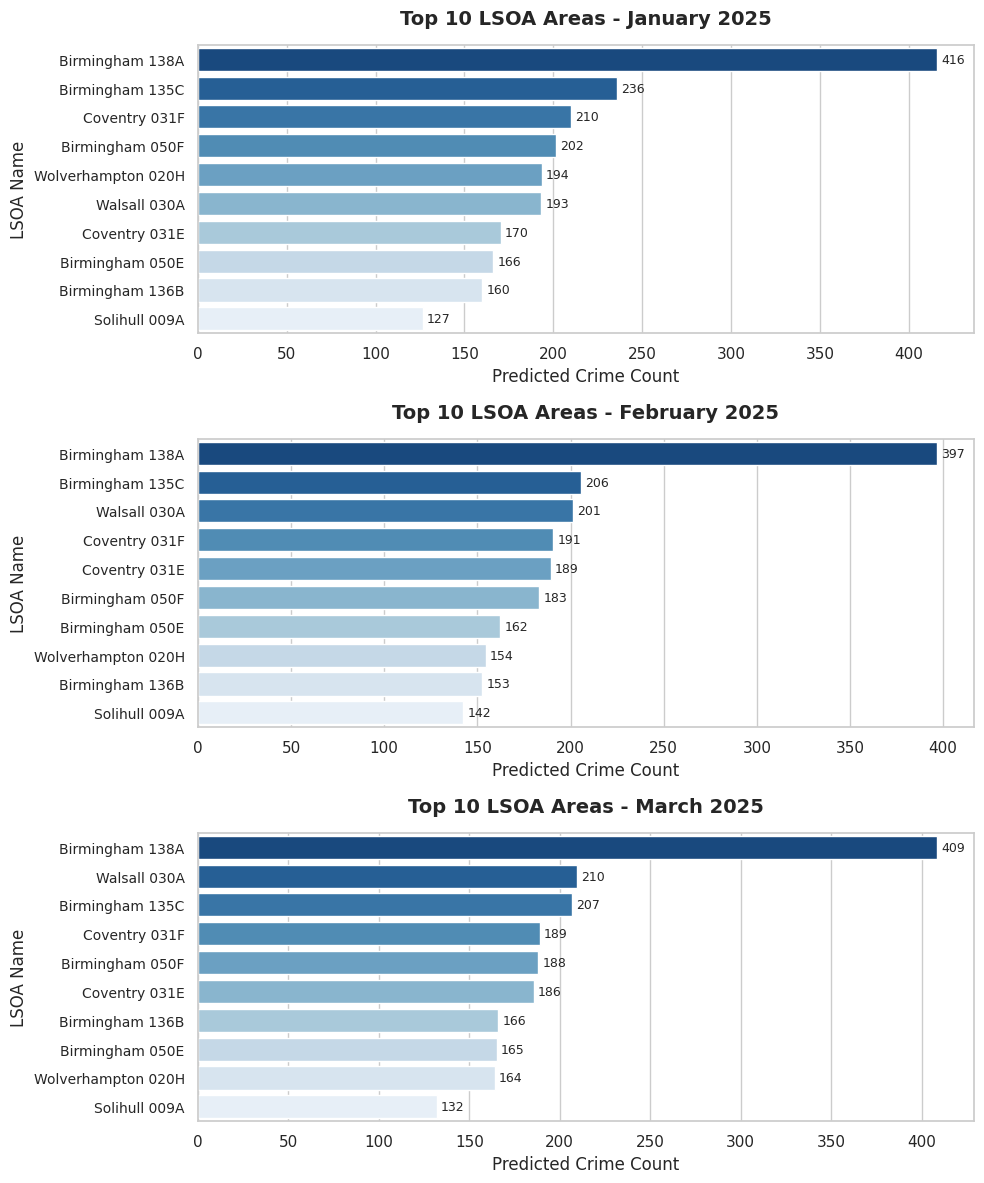

In [ ]:
# Combine predictions for January, February, and March into a single DataFrame
Ens_lsoa_tot_Jan_To_Mar = pd.concat([Ens_lsoa_tot_Jan, Ens_lsoa_tot_Feb, Ens_lsoa_tot_Mar], ignore_index=True)

# Select the top 10 LSOAs for each month based on predicted crime count
Ens_top_10_lsoa_per_month_Jan_to_Mar = Ens_lsoa_tot_Jan_To_Mar.iloc[
    Ens_lsoa_tot_Jan_To_Mar.groupby("Month")["Predicted Crime Count"]
    .apply(lambda x: x.nlargest(10).index)  # Get indices of the top 10 LSOAs by predicted crime count
    .explode().values  # Flatten the results and get the top 10 LSOAs per month
].reset_index(drop=True)  # Reset index for clarity

# Print the DataFrame with top 10 LSOAs per month (January to March)
Ens_top_10_lsoa_per_month_Jan_to_Mar

# Set the visualization style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with subplots, one for each month
months = Ens_top_10_lsoa_per_month_Jan_to_Mar["Month"].unique()  # Get unique months from the data
fig, axes = plt.subplots(nrows=len(months), figsize=(10, len(months) * 4))  # Adjust figure size based on number of months

# If only one month exists, convert the axes object to a list for consistency
if len(months) == 1:
    axes = [axes]

# Plot the top 10 LSOAs for each month
for ax, month in zip(axes, months):
    monthly_data = Ens_top_10_lsoa_per_month_Jan_to_Mar[Ens_top_10_lsoa_per_month_Jan_to_Mar["Month"] == month]  # Filter data for the current month

    # Create a bar plot for the top 10 LSOAs based on predicted crime count
    sns.barplot(
        data=monthly_data,
        y="LSOA name",  # LSOA name on the y-axis
        x="Predicted Crime Count",  # Predicted crime count on the x-axis
        hue="LSOA name",  # Use LSOA name as hue to avoid warning and give each bar a unique color
        palette="Blues_r",  # Set color palette
        legend=False,  # Disable the legend
        ax=ax  # Plot on the respective subplot axis
    )
    # Adjust font size for y-axis (LSOA names) and x-axis (predicted crime count)
    ax.tick_params(axis='y', labelsize=10)  # Adjust label size for y-axis
    ax.tick_params(axis='x', labelsize=11)  # Adjust label size for x-axis

    # Add the actual predicted crime count values on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', fontsize=9, padding=3)  # Format as integer and add padding

    # Set title and labels for the plot
    ax.set_title(f"Top 10 LSOA Areas - {month.strftime('%B %Y')}", fontsize=14, fontweight='bold', pad=15)  # Title for each subplot
    ax.set_xlabel("Predicted Crime Count", fontsize=12)  # X-axis label
    ax.set_ylabel("LSOA Name", fontsize=12 )  # Y-axis label

# Adjust layout to ensure there is no overlapping of plots
plt.tight_layout()
plt.show()  # Display the plots


## **Top 3 LSOAs Crime Map - January 2025**

**Mapping Top 3 LSOAs with Predicted Crime Counts & Crime Hotspots (Last 3 Years)**

This code identifies the top 3 LSOAs for **January 2025** based on predicted crime counts and maps the **crime hotspots** from the past 3 years within these areas. Key steps include:

1. **Top 3 LSOAs**: Selects the top 3 LSOAs with the highest predicted crime counts for **January 2025**.
2. **Crime Hotspot Mapping**: Plots **crime hotspots** (areas with high crime frequency) using **latitude** and **longitude** data from the past 3 years.
3. **Visualization**: Marks each LSOA with a unique color, and displays hotspots on the map for targeted intervention.

This map helps visualize crime concentration in key areas, aiding law enforcement and planners to focus efforts on the highest-risk locations.

In [ ]:
# Select the top 3 LSOAs for each month based on predicted crime count
Ens_top_lsoa_Name_Jan = Ens_lsoa_tot_Jan.iloc[
    Ens_lsoa_tot_Jan.groupby("Month")["Predicted Crime Count"]
    .apply(lambda x: x.nlargest(3).index)
    .explode().values
].reset_index(drop=True)

# Assuming 'Df_Street_Final' contains 'LSOA name', 'Longitude', and 'Latitude'
lsoa_coords = df_street_Final[['LSOA name', 'Longitude', 'Latitude']].drop_duplicates()

# Merge 'Ens_top_lsoa_Name_Jan' DataFrame with 'lsoa_coords' to get coordinates
Ens_top_lsoa_with_coords_Jan = pd.merge(
    Ens_top_lsoa_Name_Jan,
    lsoa_coords,
    how='left', on='LSOA name'
)

# Calculate the center of the map
center_latitude = (Ens_top_lsoa_with_coords_Jan['Latitude'].min() + Ens_top_lsoa_with_coords_Jan['Latitude'].max()) / 2
center_longitude = (Ens_top_lsoa_with_coords_Jan['Longitude'].min() + Ens_top_lsoa_with_coords_Jan['Longitude'].max()) / 2

# Create a map
m = folium.Map(location=[center_latitude, center_longitude], zoom_start=12)

# Extract unique LSOA names and assign colors
unique_lsoas = Ens_top_lsoa_with_coords_Jan['LSOA name'].unique()
fill_colors = ['blue', 'yellow', 'green']
color_map = {lsoa: fill_colors[i % len(fill_colors)] for i, lsoa in enumerate(unique_lsoas)}

# Plot top LSOAs with specific colors
for _, row in Ens_top_lsoa_with_coords_Jan.iterrows():
    fill_color = color_map.get(row['LSOA name'], 'gray')
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=8,
        color='red',  # Border color is red
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.8,
        popup=f"{row['LSOA name']} - {row['Predicted Crime Count']}",
    ).add_to(m)

# Save the map
html_path = '/content/drive/MyDrive/HTML'
os.makedirs(html_path, exist_ok=True)
html_save = os.path.join(html_path, 'top_lsoas_map.html')
m.save(html_save)

print(f"Map saved to {html_save}")

# Assuming 'm' is your folium map
display(m)

Map saved to /content/drive/MyDrive/HTML/top_lsoas_map.html
